In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =============================================================================
# METHOD 1: Using TensorBoard's Python API (Recommended)
# =============================================================================

def extract_tensorboard_data_api(log_dir):
    """
    Extract data using TensorBoard's official Python API.
    This is the most reliable method.
    
    Install required package:
    pip install tensorboard
    """
    
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    
    # Initialize the event accumulator
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()
    
    # Get all available scalar tags
    tags = event_acc.Tags()['scalars']
    print("Available metrics:", tags)
    
    # Extract data for each metric
    data_dict = {}
    
    for tag in tags:
        scalar_events = event_acc.Scalars(tag)
        
        # Extract step, timestamp, and value
        steps = [event.step for event in scalar_events]
        times = [event.wall_time for event in scalar_events]
        values = [event.value for event in scalar_events]
        
        data_dict[tag] = {
            'steps': steps,
            'wall_times': times, 
            'values': values
        }
    
    return data_dict

In [12]:
data = extract_tensorboard_data_api("/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/experiments/sensorimotor/best_params_20250411_173008_trial_460_20250621_152600/logs/events.out.tfevents.1750533960.Mac.39795.0")

Available metrics: ['vest_error', 'beat_error', 'vest_inference_error', 'beat_inference_error']


In [13]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
   'font.size': 12,
   'axes.titlesize': 14,
   'axes.labelsize': 12,
   'xtick.labelsize': 10,
   'ytick.labelsize': 10,
   'legend.fontsize': 11,
   'figure.titlesize': 16,
   'lines.linewidth': 2,
   'figure.dpi': 300,
   'savefig.dpi': 300
})

def plot_figure1a_total_error(total_error_file, smoothing_window=50, max_index=None):
   """
   Plot Figure 1A: Total prediction error decrease during training
   Shows that "training is accomplishing something" as supervisor requested
   
   Parameters:
   -----------
   total_error_file : str or array
       Path to pickle file or numpy array with total prediction errors
   smoothing_window : int
       Size of smoothing window (higher = smoother)
   max_index : int or None
       Last index to plot (None = plot all data)
   """
   
   # Load data (handle both file path and direct array)
   if isinstance(total_error_file, str):
       with open(total_error_file, 'rb') as f:
           total_errors = np.array(pickle.load(f))
   else:
       total_errors = np.array(total_error_file)
   
   print(f"Loaded total error data shape: {total_errors.shape}")
   print(f"Error range: {total_errors.min():.6f} to {total_errors.max():.6f}")
   
   # Apply max_index filter if specified
   if max_index is not None:
       total_errors = total_errors[:max_index]
       print(f"Truncated to first {max_index} points")
   
   # Create training steps (can be episodes, steps, etc.)
   training_steps = 10 * np.arange(len(total_errors))
   
   # Apply smoothing if requested
   if smoothing_window > 1:
       total_errors_smooth = uniform_filter1d(total_errors, size=smoothing_window, mode='nearest')
   else:
       total_errors_smooth = total_errors
   
   # Create figure
   fig, ax = plt.subplots(1, 1, figsize=(10, 6))
   
   # Plot total prediction error
   ax.plot(training_steps, total_errors_smooth, 'b-', linewidth=1.5, alpha=0.9)
   
   # Formatting
   ax.set_xlabel('Training Episode')
   ax.set_ylabel('Total Prediction Error')
   ax.set_title('Learning Curve: Total Prediction Error Decrease')
   ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
   
   # Use log scale for better visualization (common for learning curves)
   ax.set_yscale('log')
   
   # Make it look clean
   ax.spines['top'].set_visible(False)
   ax.spines['right'].set_visible(False)
   
   # Add text showing improvement
   improvement_ratio = total_errors[0] / total_errors[-1]
   # ax.text(0.6, 0.8, f'{improvement_ratio:.1f}x Error Reduction', 
   #         transform=ax.transAxes, fontsize=12, 
   #         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
   
   plt.tight_layout()
   plt.savefig(f'figure1a_total_error_smooth{smoothing_window}_max{max_index if max_index else "all"}.png', 
               dpi=300, bbox_inches='tight', facecolor='white')
   plt.show()
   
   # Print stats
   print(f"Training episodes: {len(total_errors)}")
   print(f"Initial error: {total_errors[0]:.6f}")
   print(f"Final error: {total_errors[-1]:.6f}")
   print(f"Error reduction: {improvement_ratio:.1f}x")
   
   return total_errors

# Use it:
# plot_figure1a_total_error('total_errors.pkl')
# plot_figure1a_total_error(your_array, smoothing_window=100, max_index=1000)

Available metrics: ['vest_error', 'beat_error', 'vest_inference_error', 'beat_inference_error']
Loaded total error data shape: (651,)
Error range: 0.119850 to 0.213202
Truncated to first 1000 points


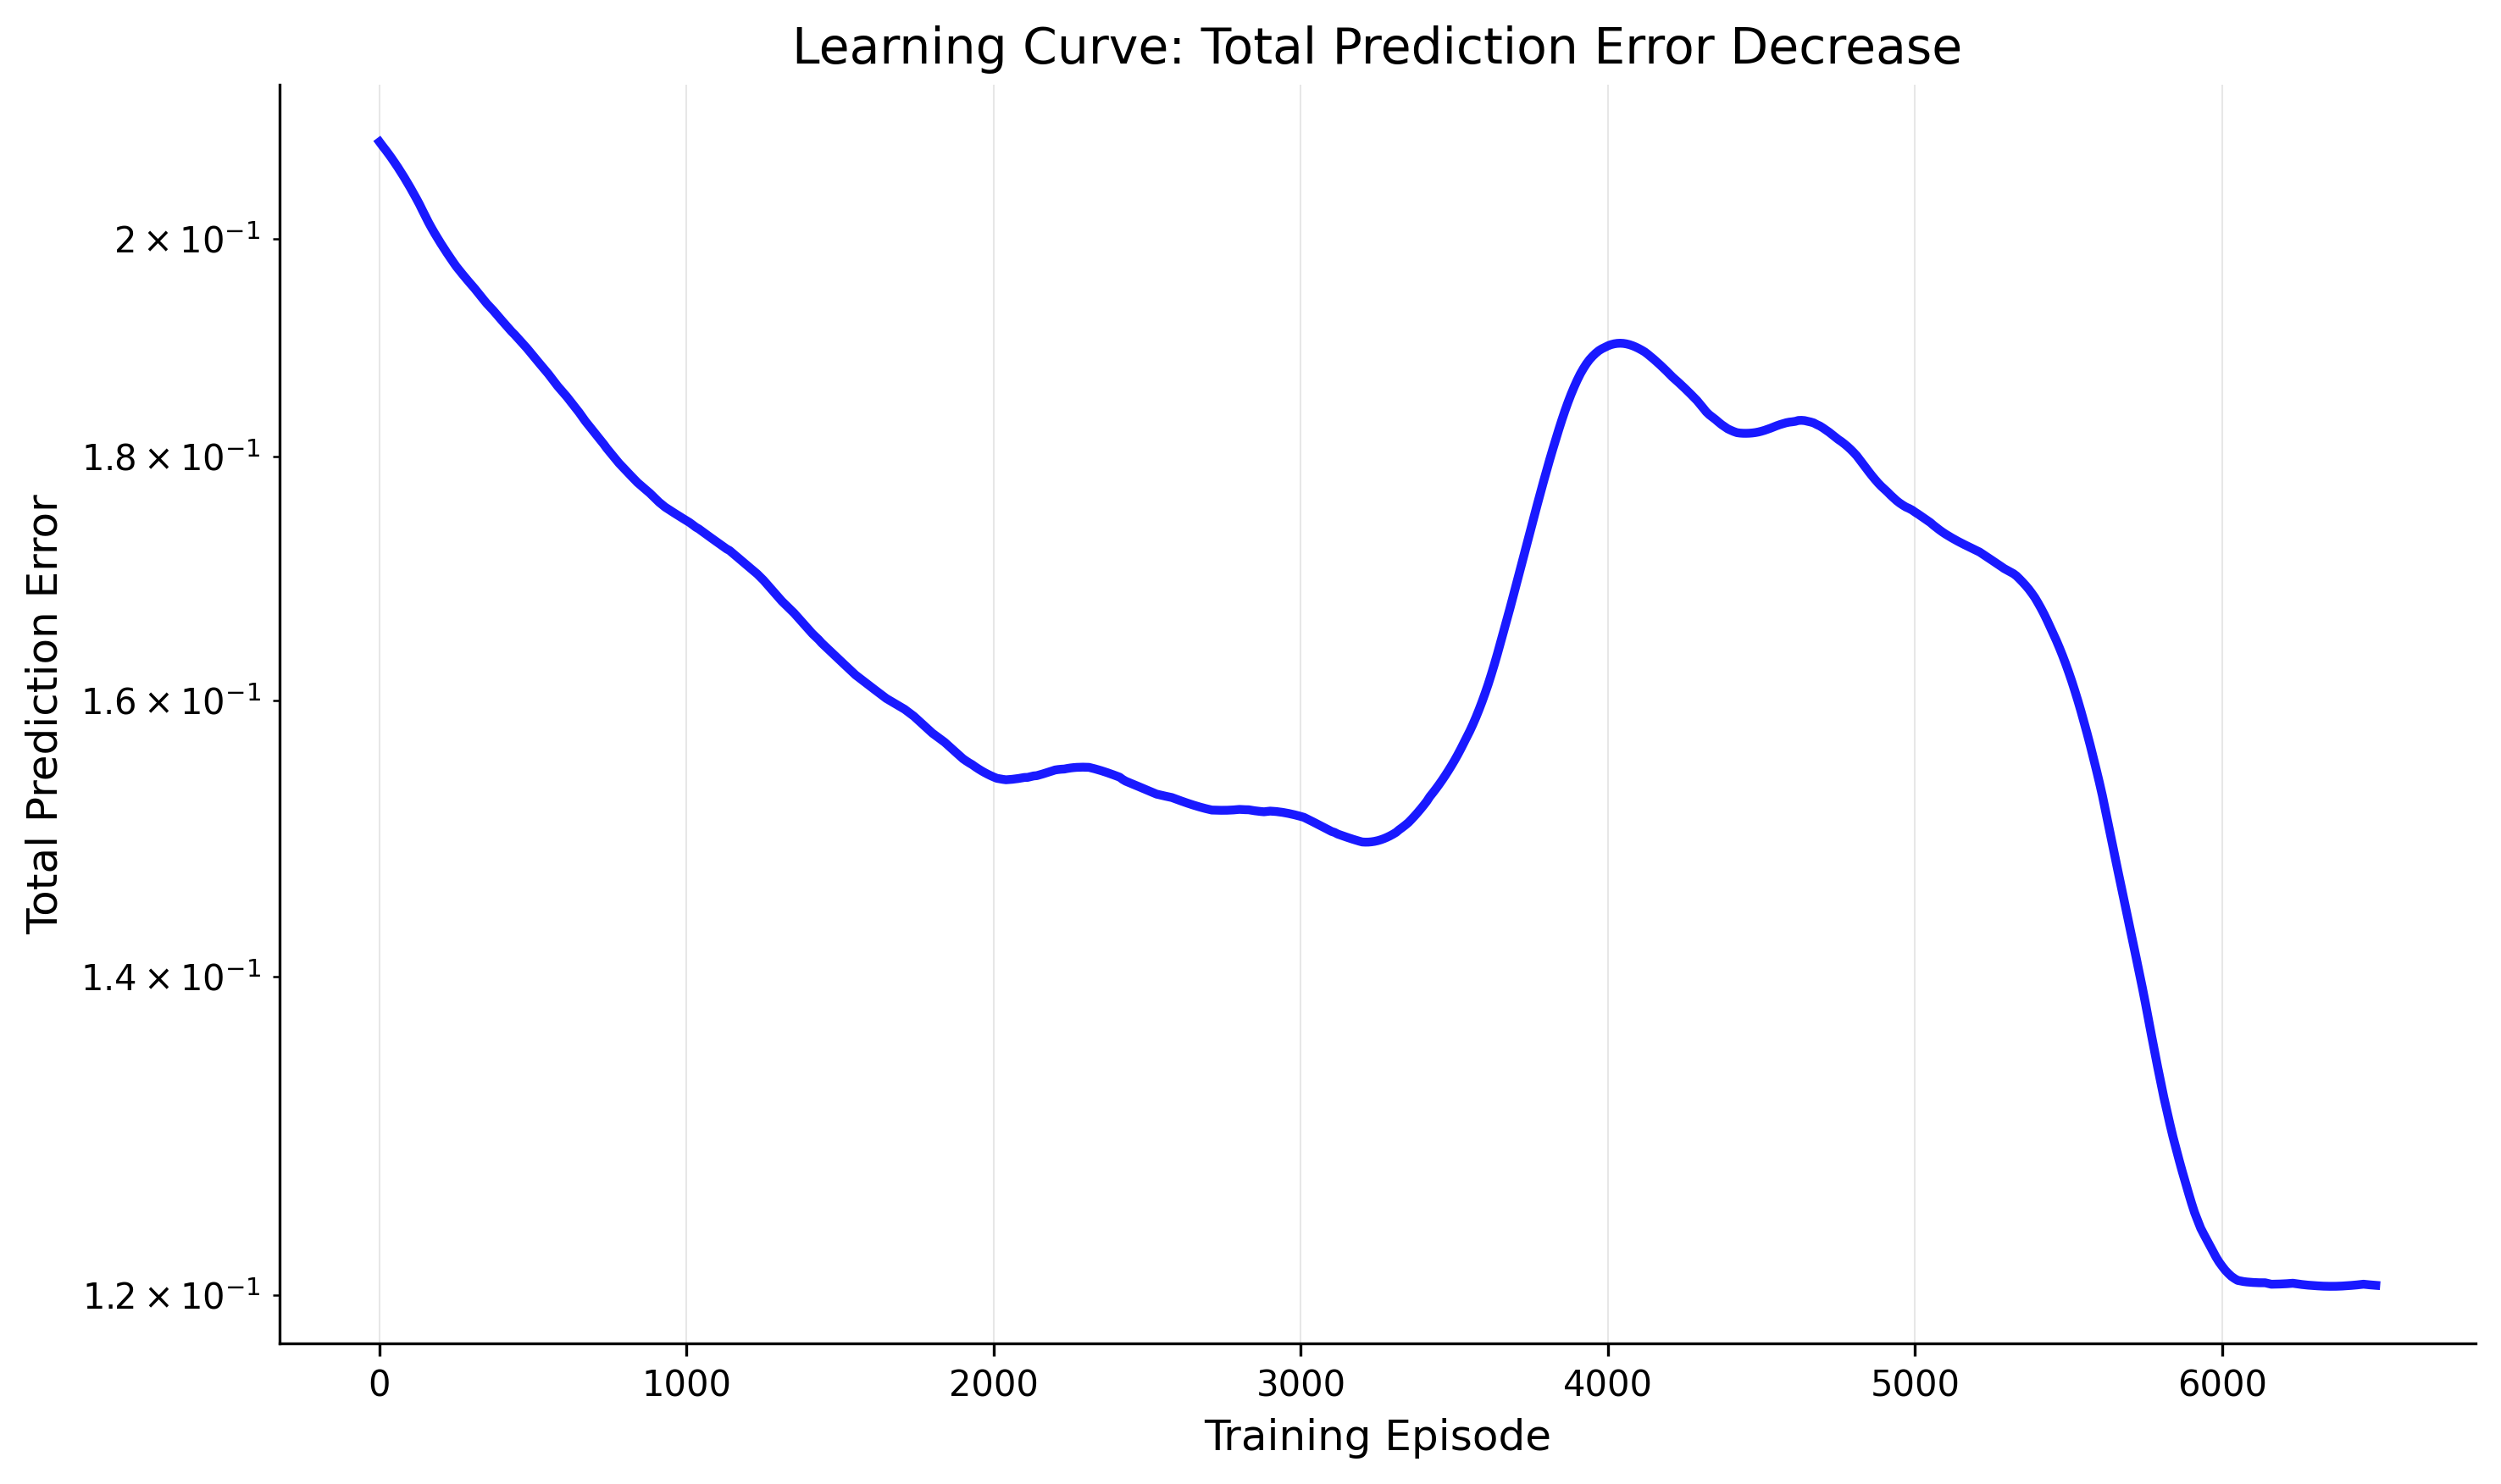

Training episodes: 651
Initial error: 0.213202
Final error: 0.120488
Error reduction: 1.8x


array([0.21320172, 0.2110662 , 0.20984913, 0.20883827, 0.20789139,
       0.20703562, 0.20627203, 0.20554895, 0.20484427, 0.20415632,
       0.20352746, 0.20291036, 0.20230407, 0.20174769, 0.20119721,
       0.20065373, 0.20126441, 0.20076347, 0.20027304, 0.19980125,
       0.199338  , 0.19888264, 0.19842972, 0.19798521, 0.19754739,
       0.19711277, 0.19668999, 0.19626873, 0.19479474, 0.19554345,
       0.19514313, 0.19474342, 0.19434486, 0.19394857, 0.19355449,
       0.19316259, 0.19277946, 0.19240161, 0.19202764, 0.19165742,
       0.19244888, 0.1920863 , 0.1917263 , 0.19136802, 0.19101306,
       0.19066018, 0.19031306, 0.18997008, 0.18962856, 0.18928731,
       0.19010059, 0.18975672, 0.18831643, 0.18797938, 0.18764588,
       0.18731267, 0.18698088, 0.1866503 , 0.18632773, 0.18600987,
       0.18569202, 0.18537096, 0.18505138, 0.18362702, 0.18331582,
       0.18300566, 0.18269561, 0.18238851, 0.18208438, 0.18177929,
       0.18147918, 0.18118006, 0.18088082, 0.18174341, 0.18144

In [14]:
data = extract_tensorboard_data_api("/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/experiments/sensorimotor/best_params_20250411_173008_trial_460_20250621_152600/logs/events.out.tfevents.1750533960.Mac.39795.0")

arr = np.array(data['beat_error']['values'][:750]) + np.array(data['vest_error']['values'][:750])
# arr = np.array(data['beat_error']['values'][:750])
# arr = np.array(data['vest_error']['values'][:750])
# arr = float_list[1:]
window = 100
ma = np.mean([arr[i:i+window] for i in range(len(arr) - window + 1)], axis=1)
# plt.plot(ma)

plot_figure1a_total_error(ma, smoothing_window=30, max_index=1000)


/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_10030/1040930987.py:41: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data[key] = np.array(pickle.load(f))


Vestibular y-limits: [np.float32(-1.2), np.float32(1.2)]
Auditory y-limits: [np.float64(-0.33617745637893676), np.float64(1.1214706778526307)]


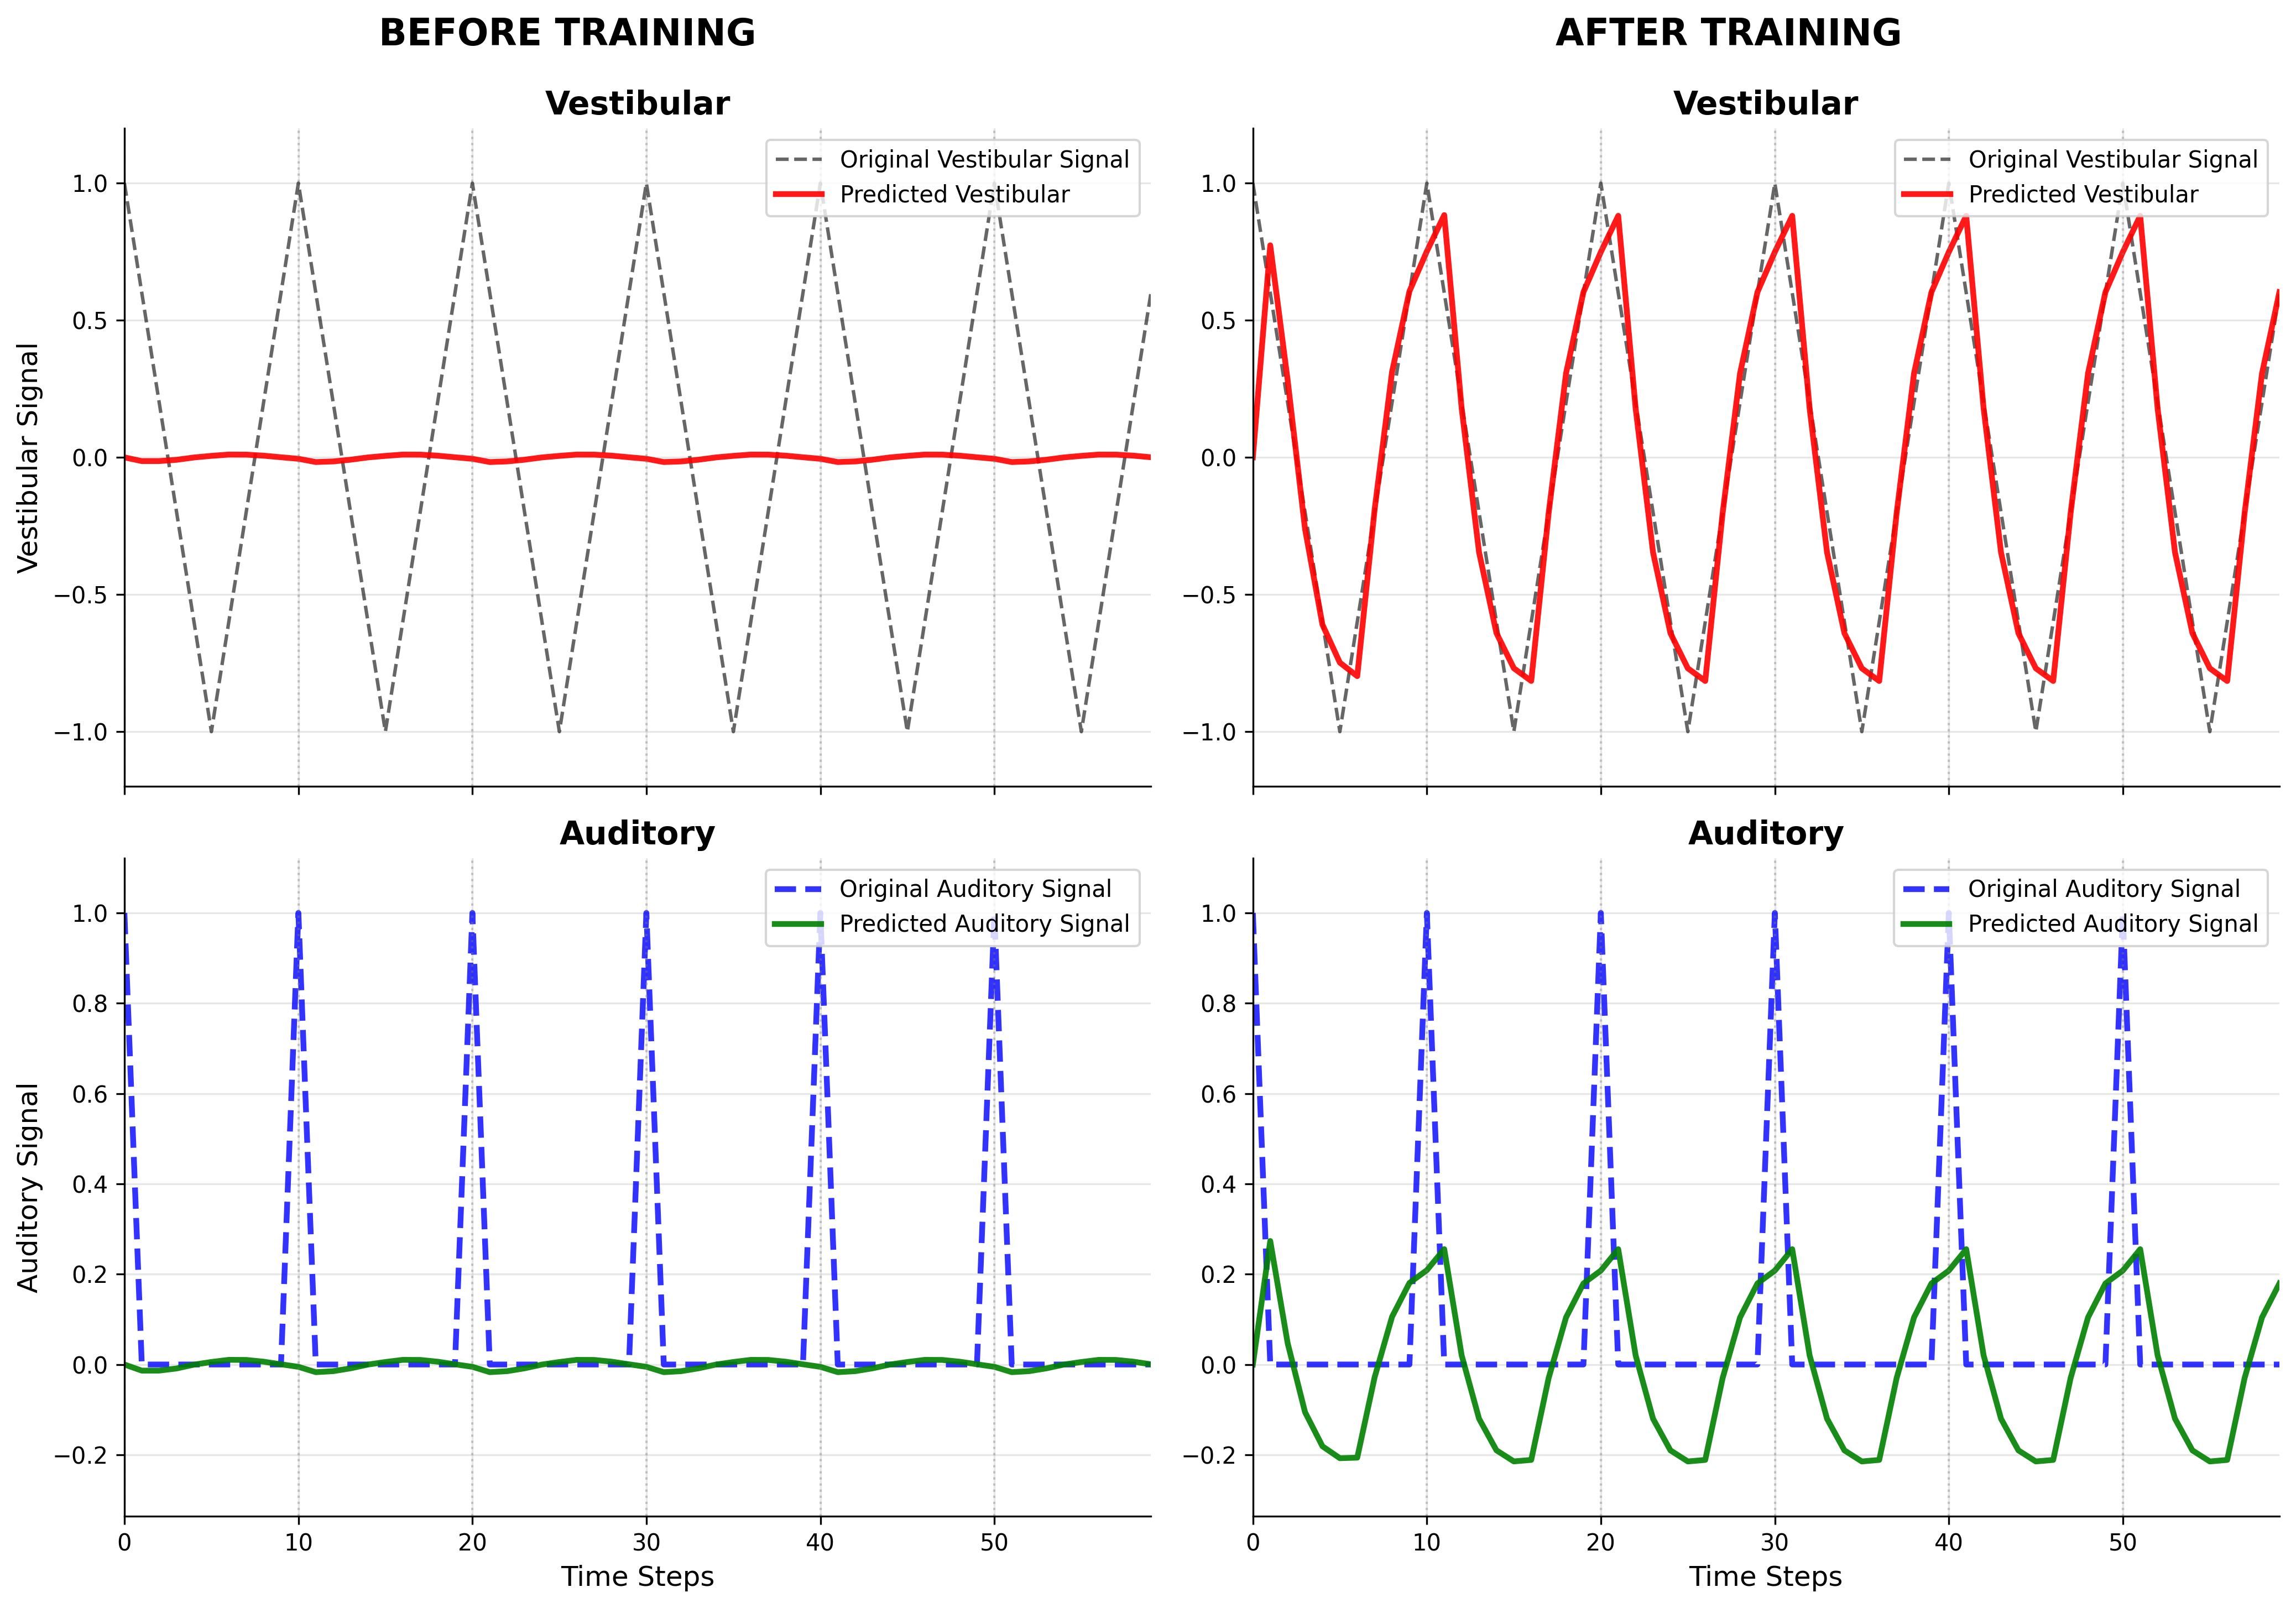

Showing 6 cycles (60 time steps)
Y-axis limits automatically adjusted to show ALL data values


In [30]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'lines.linewidth': 2,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

def plot_figure1b_before_after(max_cycles=4):
    """
    Plot Figure 1B: Before/After training comparison with 2x2 subplot layout
    Y-axis limits adjusted to show ALL data values (no vertical clipping)
    """
    
    # Load all data files
    files = {
       'beat_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_before.pkl',
       'beat_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_after.pkl', 
       'beat_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_before.pkl',
       'beat_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_after.pkl',
       'vest_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_before.pkl',
       'vest_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_after.pkl',
       'vest_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_before.pkl',
       'vest_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_after.pkl'
   }
    
    data = {}
    for key, filename in files.items():
        with open(filename, 'rb') as f:
            data[key] = np.array(pickle.load(f))
    
    # Find the minimum length across all arrays
    min_length = min([len(data[key]) for key in data.keys()])
    
    # Estimate cycle length and limit data
    beat_peaks = np.where(data['beat_seq_after'] > 0.5)[0]
    if len(beat_peaks) > 1:
        cycle_length = beat_peaks[1] - beat_peaks[0]
    else:
        cycle_length = 100
    
    max_points = min(max_cycles * cycle_length, min_length)
    
    # Apply same truncation to ALL arrays
    for key in data:
        data[key] = data[key][:max_points]
    
    time_steps = np.arange(max_points)
    
    # Calculate y-axis limits for each signal type to show ALL data
    vest_min = min(data['vest_seq_before'].min(), data['vest_seq_after'].min(), 
                   data['vest_pred_before'].min(), data['vest_pred_after'].min())
    vest_max = max(data['vest_seq_before'].max(), data['vest_seq_after'].max(), 
                   data['vest_pred_before'].max(), data['vest_pred_after'].max())
    vest_margin = (vest_max - vest_min) * 0.1  # 10% margin
    vest_ylim = [vest_min - vest_margin, vest_max + vest_margin]
    
    beat_min = min(data['beat_seq_before'].min(), data['beat_seq_after'].min(), 
                   data['beat_pred_before'].min(), data['beat_pred_after'].min())
    beat_max = max(data['beat_seq_before'].max(), data['beat_seq_after'].max(), 
                   data['beat_pred_before'].max(), data['beat_pred_after'].max())
    beat_margin = (beat_max - beat_min) * 0.1  # 10% margin
    beat_ylim = [beat_min - beat_margin, beat_max + beat_margin]
    
    print(f"Vestibular y-limits: {vest_ylim}")
    print(f"Auditory y-limits: {beat_ylim}")
    
    # Create 2x2 subplot layout
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    
    # BEFORE TRAINING - VESTIBULAR (Top Left)
    ax1.plot(time_steps, data['vest_seq_before'], 'k--', linewidth=1.5, 
             alpha=0.6, label='Original Vestibular Signal')
    ax1.plot(time_steps, data['vest_pred_before'], 'r-', linewidth=1.5, 
             label='Predicted Vestibular', alpha=0.9)
    ax1.set_title('Vestibular', fontweight='bold')
    ax1.set_ylabel('Vestibular Signal')
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(vest_ylim)  # Dynamic y-limits
    
    # AFTER TRAINING - VESTIBULAR (Top Right)
    ax2.plot(time_steps, data['vest_seq_after'], 'k--', linewidth=1.5, 
             alpha=0.6, label='Original Vestibular Signal')
    ax2.plot(time_steps, data['vest_pred_after'], 'r-', linewidth=1.5, 
             label='Predicted Vestibular', alpha=0.9)
    ax2.set_title('Vestibular', fontweight='bold')
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(vest_ylim)  # Same y-limits as left panel
    
    # BEFORE TRAINING - BEAT (Bottom Left)
    ax3.plot(time_steps, data['beat_seq_before'], 'b--', linewidth=1.5, 
             label='Original Auditory Signal', alpha=0.8)
    ax3.plot(time_steps, data['beat_pred_before'], 'g-', linewidth=1.5, 
             label='Predicted Auditory Signal', alpha=0.9)
    ax3.set_title('Auditory', fontweight='bold')
    ax3.set_xlabel('Time Steps')
    ax3.set_ylabel('Auditory Signal')
    ax3.legend(loc="upper right")
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(beat_ylim)  # Dynamic y-limits
    
    # AFTER TRAINING - BEAT (Bottom Right)
    ax4.plot(time_steps, data['beat_seq_after'], 'b--', linewidth=1.5, 
             label='Original Auditory Signal', alpha=0.8)
    ax4.plot(time_steps, data['beat_pred_after'], 'g-', linewidth=1.5, 
             label='Predicted Auditory Signal', alpha=0.9)
    ax4.set_title('Auditory', fontweight='bold')
    ax4.set_xlabel('Time Steps')
    ax4.legend(loc="upper right")
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(beat_ylim)  # Same y-limits as left panel
    
    # Set consistent x-axis limits
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlim(0, max_points-1)
    
    # Add vertical alignment lines
    beat_times_before = time_steps[data['beat_seq_before'] > 0.5]
    beat_times_after = time_steps[data['beat_seq_after'] > 0.5]
    
    for beat_time in beat_times_before:
        ax1.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        ax3.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
    
    for beat_time in beat_times_after:
        ax2.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        ax4.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        
    # Remove top and right spines
    for ax in [ax1, ax2, ax3, ax4]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Add overall figure labels
    fig.text(0.25, 0.95, 'BEFORE TRAINING', ha='center', fontsize=16, fontweight='bold')
    fig.text(0.75, 0.95, 'AFTER TRAINING', ha='center', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig(f'figure1b_before_after_full_range_{max_cycles}cycles.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"Showing {max_cycles} cycles ({max_points} time steps)")
    print("Y-axis limits automatically adjusted to show ALL data values")

# Use it:
plot_figure1b_before_after(max_cycles=6)

/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_10030/3878820828.py:48: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data[key] = np.array(pickle.load(f))


Detected 40 cycles, each 10 steps long
Showing cycles 2 to 7 (indices 20 to 79)


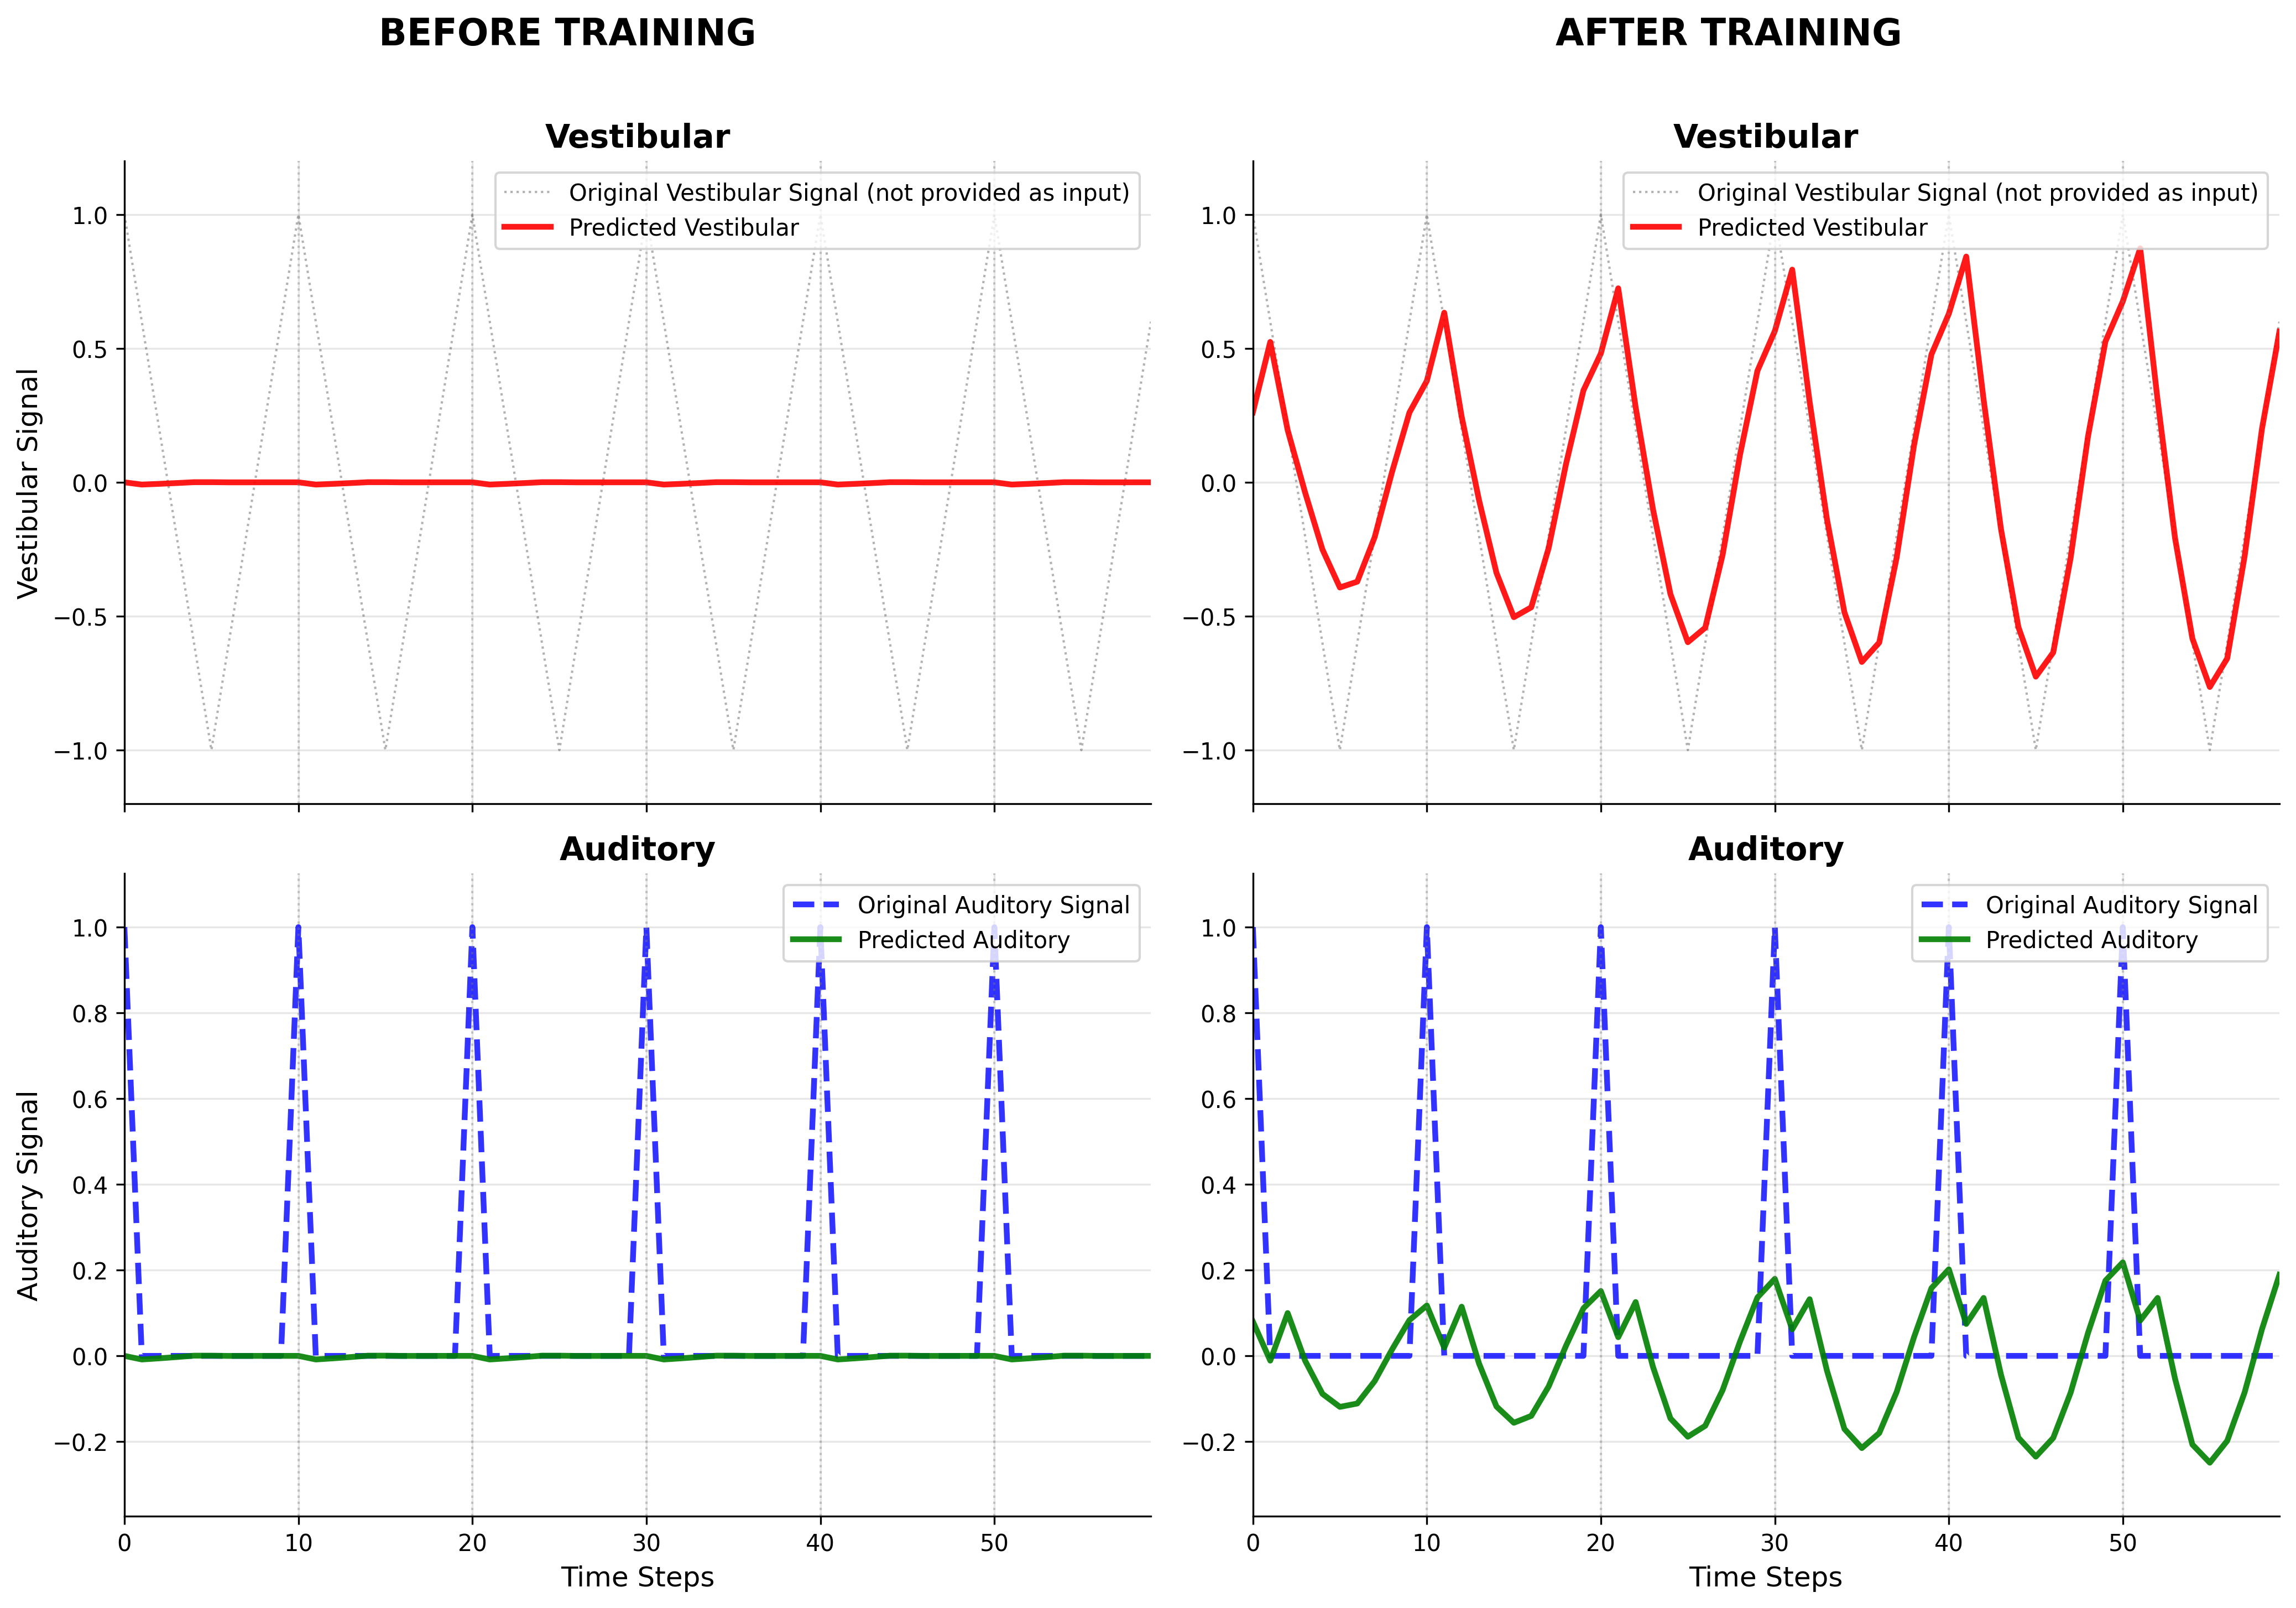

Showing cycles 2 to 7
Total time steps shown: 60


In [21]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
   'font.size': 12,
   'axes.titlesize': 14,
   'axes.labelsize': 12,
   'xtick.labelsize': 10,
   'ytick.labelsize': 10,
   'legend.fontsize': 10,
   'figure.titlesize': 16,
   'lines.linewidth': 2,
   'figure.dpi': 300,
   'savefig.dpi': 300
})

def plot_figure2_auditory_only(start_cycle=0, end_cycle=4):
   """
   Plot Figure 2: Auditory-only condition showing vestibular predictions from beat input
   Before/After comparison with auditory-only input (no vestibular input provided)
   
   Parameters:
   -----------
   start_cycle : int
       Starting cycle number (0-based)
   end_cycle : int
       Ending cycle number (0-based)
   """
   
   # Load all data files
   files = {
       'beat_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_before_auditory_rhythm.pkl',
       'beat_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_after_auditory_rhythm.pkl', 
       'beat_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_before_auditory_rhythm.pkl',
       'beat_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_after_auditory_rhythm.pkl',
       'vest_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_before_auditory_rhythm.pkl',
       'vest_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_after_auditory_rhythm.pkl',
       'vest_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_before_auditory_rhythm.pkl',
       'vest_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_after_auditory_rhythm.pkl'
   }
   
   data = {}
   for key, filename in files.items():
       with open(filename, 'rb') as f:
           data[key] = np.array(pickle.load(f))
   
   # Detect cycle boundaries from beat sequence
   beat_peaks = np.where(data['beat_seq_after'] > 0.5)[0]
   
   if len(beat_peaks) < 2:
       print("Error: Could not detect beat cycles!")
       return
   
   cycle_length = beat_peaks[1] - beat_peaks[0]
   total_cycles = len(beat_peaks)
   
   print(f"Detected {total_cycles} cycles, each {cycle_length} steps long")
   
   # Validate cycle range
   if start_cycle >= total_cycles or end_cycle > total_cycles:
       print(f"Error: Requested cycles {start_cycle}-{end_cycle} exceed available cycles (0-{total_cycles-1})")
       return
   
   if start_cycle >= end_cycle:
       print("Error: start_cycle must be less than end_cycle")
       return
   
   # Calculate start and end indices
   start_idx = start_cycle * cycle_length
   end_idx = end_cycle * cycle_length
   
   print(f"Showing cycles {start_cycle} to {end_cycle-1} (indices {start_idx} to {end_idx-1})")
   
   # Extract the desired time window from all arrays
   for key in data:
       data[key] = data[key][start_idx:end_idx]
   
   time_steps = np.arange(len(data['vest_pred_before']))
   
   # Calculate y-axis limits to show all data
   vest_min = min(data['vest_seq_before'].min(), data['vest_seq_after'].min(), 
                  data['vest_pred_before'].min(), data['vest_pred_after'].min())
   vest_max = max(data['vest_seq_before'].max(), data['vest_seq_after'].max(), 
                  data['vest_pred_before'].max(), data['vest_pred_after'].max())
   vest_margin = (vest_max - vest_min) * 0.1
   vest_ylim = [vest_min - vest_margin, vest_max + vest_margin]
   
   beat_min = min(data['beat_seq_before'].min(), data['beat_seq_after'].min(), 
                  data['beat_pred_before'].min(), data['beat_pred_after'].min())
   beat_max = max(data['beat_seq_before'].max(), data['beat_seq_after'].max(), 
                  data['beat_pred_before'].max(), data['beat_pred_after'].max())
   beat_margin = (beat_max - beat_min) * 0.1
   beat_ylim = [beat_min - beat_margin, beat_max + beat_margin]
   
   # Create 2x2 subplot layout
   fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
   
   # BEFORE TRAINING - VESTIBULAR (Top Left)
   ax1.plot(time_steps, data['vest_seq_before'], 'k:', linewidth=1, 
            alpha=0.3, label='Original Vestibular Signal (not provided as input)')
   ax1.plot(time_steps, data['vest_pred_before'], 'r-', linewidth=1.5, 
            label='Predicted Vestibular', alpha=0.9)
   ax1.set_title('Vestibular', fontweight='bold')
   ax1.set_ylabel('Vestibular Signal')
   ax1.legend(loc="upper right")
   ax1.grid(True, alpha=0.3)
   ax1.set_ylim(vest_ylim)
   
   # AFTER TRAINING - VESTIBULAR (Top Right)
   ax2.plot(time_steps, data['vest_seq_after'], 'k:', linewidth=1, 
            alpha=0.3, label='Original Vestibular Signal (not provided as input)')
   ax2.plot(time_steps, data['vest_pred_after'], 'r-', linewidth=1.5, 
            label='Predicted Vestibular', alpha=0.9)
   ax2.set_title('Vestibular', fontweight='bold')
   ax2.legend(loc="upper right")
   ax2.grid(True, alpha=0.3)
   ax2.set_ylim(vest_ylim)
   
   # BEFORE TRAINING - BEAT (Bottom Left)
   ax3.plot(time_steps, data['beat_seq_before'], 'b--', linewidth=1.5, 
            label='Original Auditory Signal', alpha=0.8)
   ax3.plot(time_steps, data['beat_pred_before'], 'g-', linewidth=1.5, 
            label='Predicted Auditory Signal', alpha=0.9)
   ax3.set_title('Auditory', fontweight='bold')
   ax3.set_xlabel('Time Steps')
   ax3.set_ylabel('Auditory Signal')
   ax3.legend(loc="upper right")
   ax3.grid(True, alpha=0.3)
   ax3.set_ylim(beat_ylim)
   
   # AFTER TRAINING - BEAT (Bottom Right)
   ax4.plot(time_steps, data['beat_seq_after'], 'b--', linewidth=1.5, 
            label='Original Auditory Signal', alpha=0.8)
   ax4.plot(time_steps, data['beat_pred_after'], 'g-', linewidth=1.5, 
            label='Predicted Auditory Signal', alpha=0.9)
   ax4.set_title('Auditory', fontweight='bold')
   ax4.set_xlabel('Time Steps')
   ax4.legend(loc="upper right")
   ax4.grid(True, alpha=0.3)
   ax4.set_ylim(beat_ylim)
   
   # Set consistent x-axis limits
   for ax in [ax1, ax2, ax3, ax4]:
       ax.set_xlim(0, len(time_steps)-1)
   
   # Add vertical alignment lines at beat times
   beat_times_before = time_steps[data['beat_seq_before'] > 0.5]
   beat_times_after = time_steps[data['beat_seq_after'] > 0.5]
   
   for beat_time in beat_times_before:
       ax1.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
       ax3.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
   
   for beat_time in beat_times_after:
       ax2.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
       ax4.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
   
   # Add annotations to emphasize key points
   # ax1.text(0.5, 0.9, 'No Vestibular\nInput Given', transform=ax1.transAxes, 
   #          ha='center', va='center', fontsize=10, style='italic',
   #          bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
   # 
   # ax2.text(0.5, 0.9, 'Vestibular Predicted\nFrom Auditory Only!', transform=ax2.transAxes, 
   #          ha='center', va='center', fontsize=10, style='italic',
   #          bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))
   # 
   # ax3.text(0.5, 0.05, 'Auditory Input\nProvided', transform=ax3.transAxes, 
   #          ha='center', va='center', fontsize=10, style='italic',
   #          bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
   # 
   # ax4.text(0.5, 0.05, 'Auditory Input\nProvided', transform=ax4.transAxes, 
   #          ha='center', va='center', fontsize=10, style='italic',
   #          bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
   
   # Remove top and right spines
   for ax in [ax1, ax2, ax3, ax4]:
       ax.spines['top'].set_visible(False)
       ax.spines['right'].set_visible(False)
   
   # Add overall figure labels
   fig.text(0.25, 0.95, 'BEFORE TRAINING', ha='center', fontsize=16, fontweight='bold')
   fig.text(0.75, 0.95, 'AFTER TRAINING', ha='center', fontsize=16, fontweight='bold')
   
   # Add main title with cycle info
   # fig.suptitle(f'Auditory-Only Input: Cycles {start_cycle}-{end_cycle-1}', 
   #              fontsize=18, fontweight='bold', y=0.98)
   
   plt.tight_layout()
   plt.subplots_adjust(top=0.88)
   plt.savefig(f'figure2_auditory_only_cycles{start_cycle}to{end_cycle-1}.png', 
               dpi=300, bbox_inches='tight', facecolor='white')
   plt.show()
   
   print(f"Showing cycles {start_cycle} to {end_cycle-1}")
   print(f"Total time steps shown: {len(time_steps)}")

# Examples:
# Show cycles 0-4 (first 4 cycles)
plot_figure2_auditory_only(start_cycle=2, end_cycle=8)

# Show cycles 10-14 (as you requested)
# plot_figure2_auditory_only(start_cycle=10, end_cycle=14)

# Show cycles 5-8
# plot_figure2_auditory_only(start_cycle=5, end_cycle=8)

/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_10030/3320055990.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  vest_input = np.array(pickle.load(f))
/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_10030/3320055990.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  beat_input = np.array(pickle.load(f))


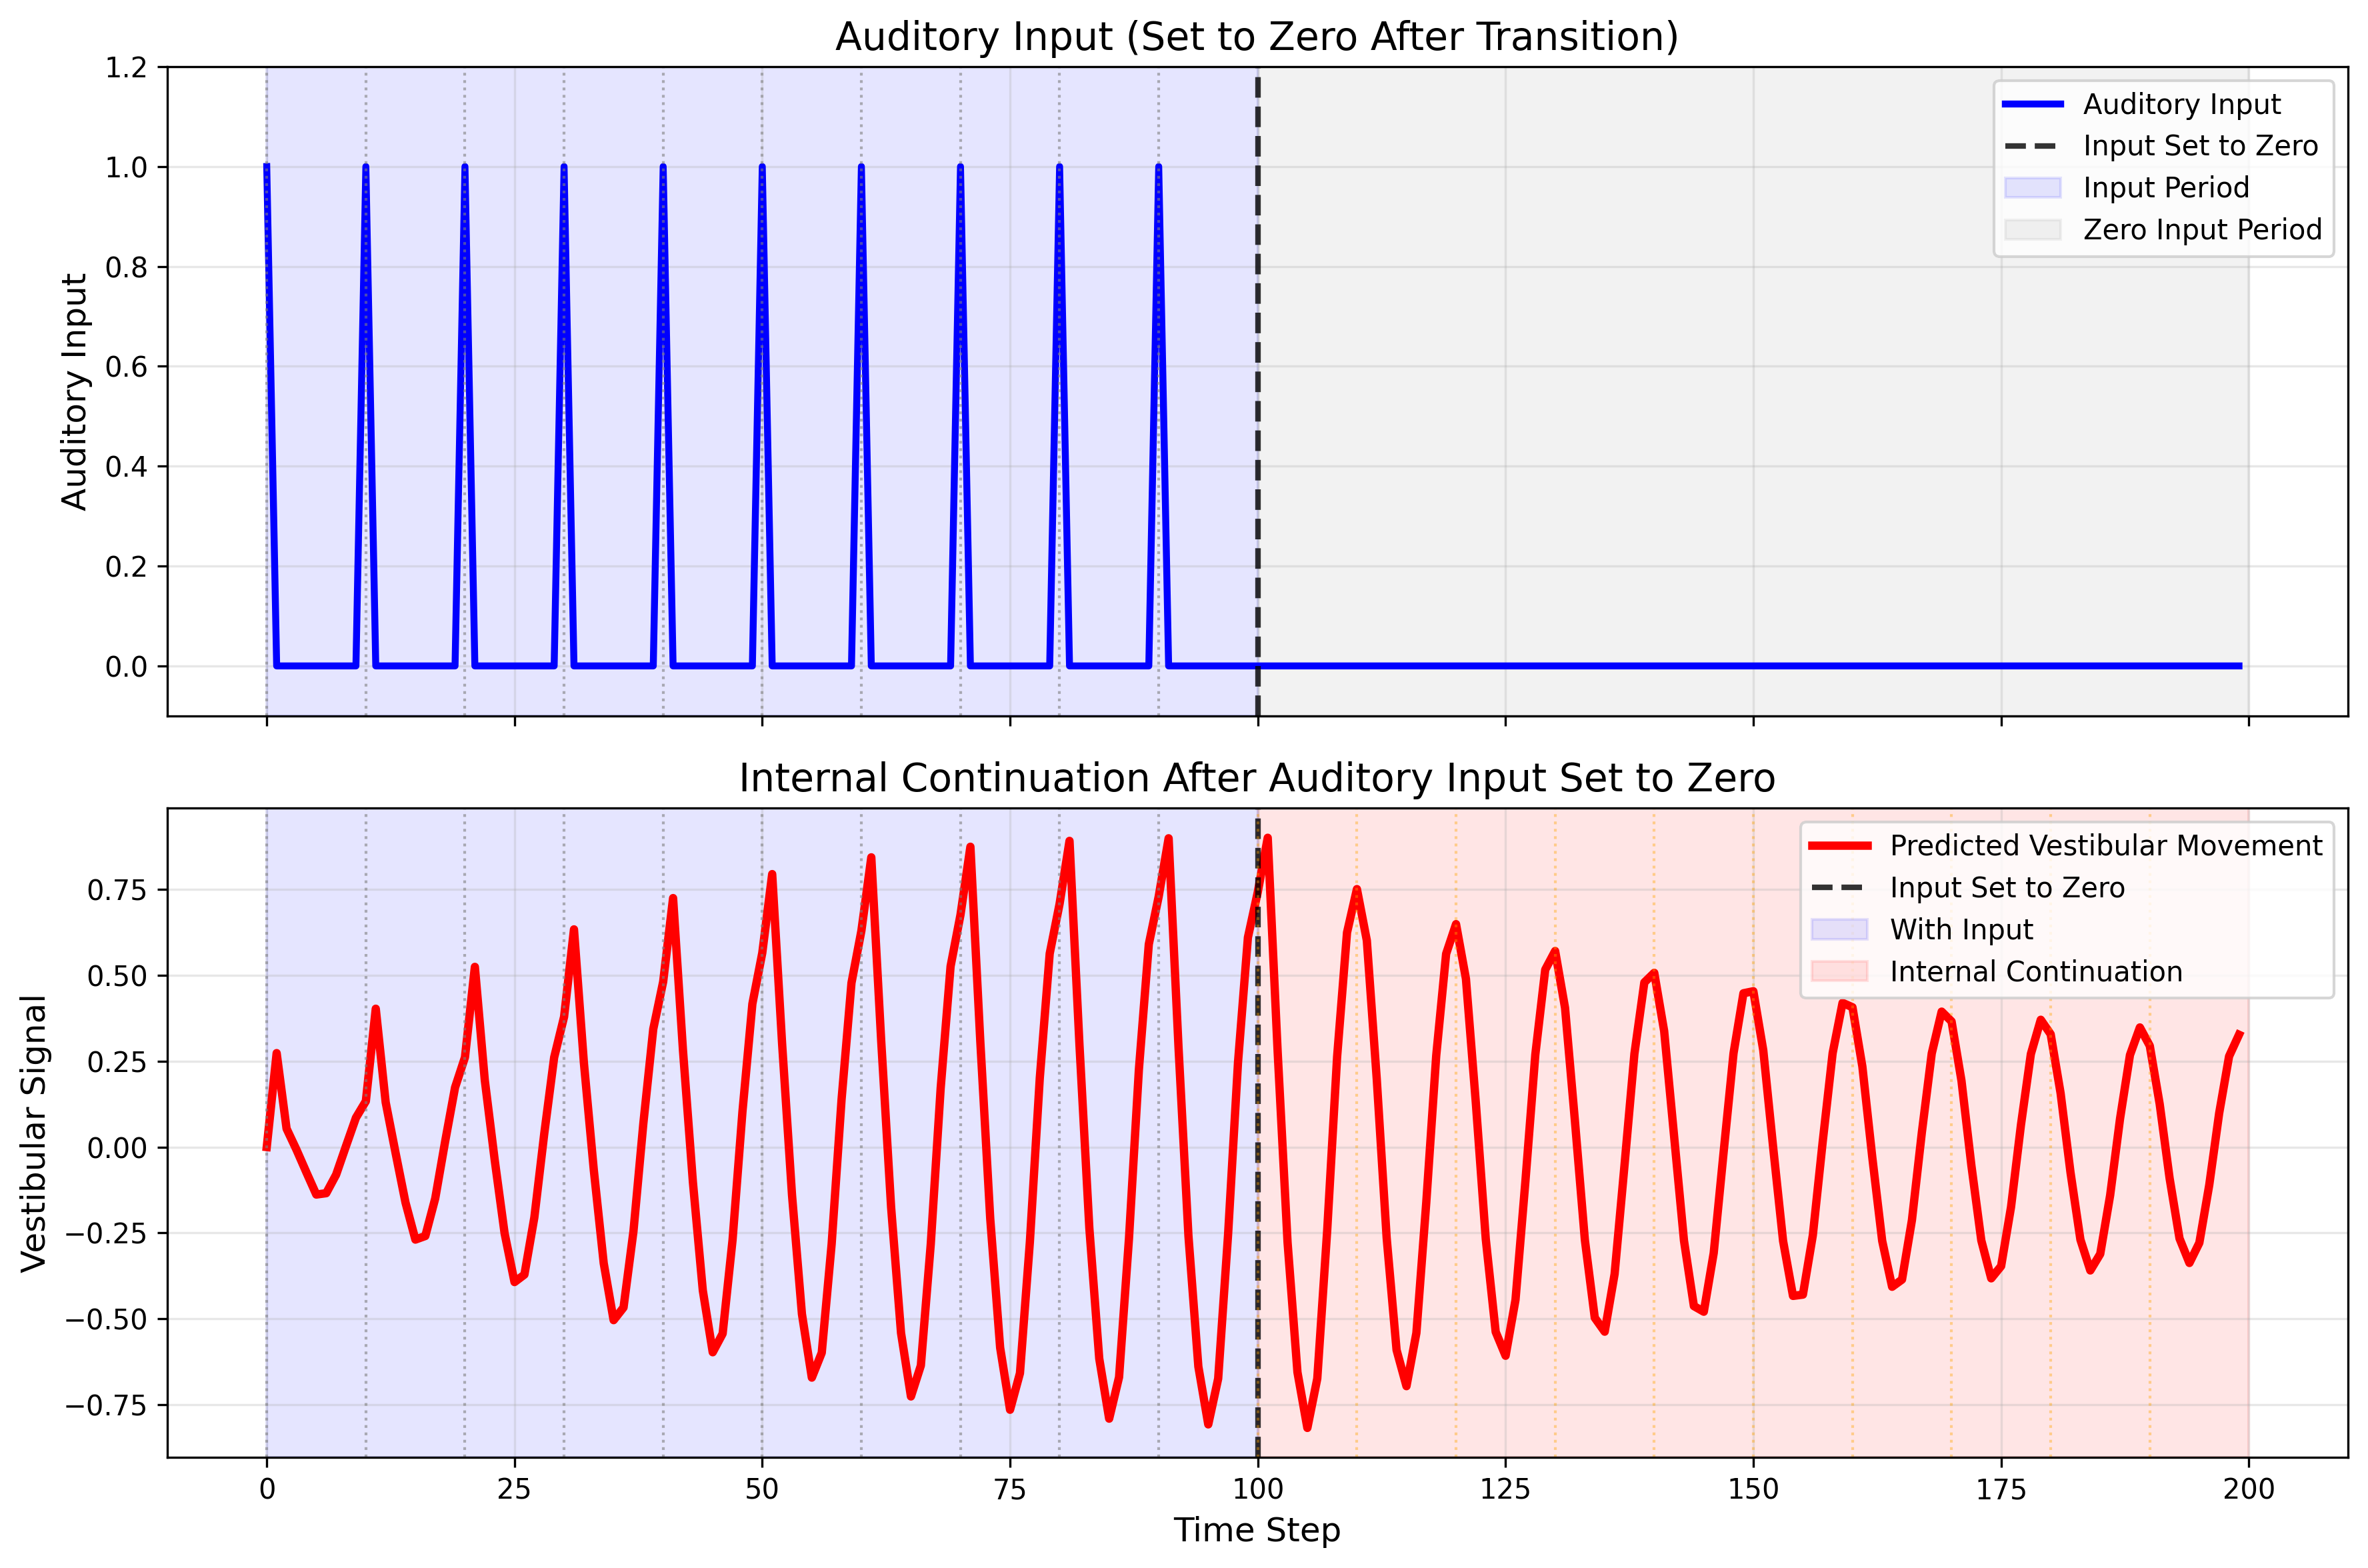

In [22]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

def plot_figure3(pred_vest_file, pred_beat_file, vest_input_file, beat_input_file, 
                 transition_point=None, max_points=None):
    # Load data
    with open(pred_vest_file, 'rb') as f:
        pred_vest = np.array(pickle.load(f))
    with open(pred_beat_file, 'rb') as f:
        pred_beat = np.array(pickle.load(f))
    with open(vest_input_file, 'rb') as f:
        vest_input = np.array(pickle.load(f))
    with open(beat_input_file, 'rb') as f:
        beat_input = np.array(pickle.load(f))
    
    if max_points:
        pred_vest = pred_vest[:max_points]
        pred_beat = pred_beat[:max_points]
        vest_input = vest_input[:max_points]
        beat_input = beat_input[:max_points]
    
    # Auto-detect transition point if not provided (halfway)
    if transition_point is None:
        transition_point = len(pred_vest) // 2
    
    time = np.arange(len(pred_vest))
    
    # Modify beat input to show it being set to zero after transition
    beat_input_modified = beat_input.copy()
    beat_input_modified[transition_point:] = 0  # Set to zero after transition
    
    # Create 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Top subplot: Auditory input (full line, but shows zeros after transition)
    ax1.plot(time, beat_input_modified, 'b-', linewidth=1.5, label='Auditory Input')
    ax1.set_ylabel('Auditory Input')
    ax1.set_title('Auditory Input (Set to Zero After Transition)')
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.1, 1.2)  # Make sure we can see the zero line clearly
    
    # Bottom subplot: Vestibular prediction (continuous)
    ax2.plot(time, pred_vest, 'r-', linewidth=3, label='Predicted Vestibular Movement')
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Vestibular Signal')
    ax2.set_title('Internal Continuation After Auditory Input Set to Zero')
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)
    
    # Add transition marker
    ax1.axvline(x=transition_point, color='black', linestyle='--', linewidth=2, alpha=0.8,
                label='Input Set to Zero')
    ax2.axvline(x=transition_point, color='black', linestyle='--', linewidth=2, alpha=0.8, 
                label='Input Set to Zero')
    
    # Add shaded regions
    ax1.axvspan(0, transition_point, alpha=0.1, color='blue', label='Input Period')
    ax1.axvspan(transition_point, len(time), alpha=0.1, color='gray', label='Zero Input Period')
    
    ax2.axvspan(0, transition_point, alpha=0.1, color='blue', label='With Input')
    ax2.axvspan(transition_point, len(time), alpha=0.1, color='red', label='Internal Continuation')
    
    # Add alignment lines for ENTIRE duration (including continuation)
    # Use the original beat pattern to show internal rhythm continues
    beat_peaks = time[beat_input > 0.5]
    for peak_time in beat_peaks:
        if peak_time < transition_point:
            # Input period - solid lines
            ax1.axvline(x=peak_time, color='gray', linestyle=':', alpha=0.6, linewidth=1)
            ax2.axvline(x=peak_time, color='gray', linestyle=':', alpha=0.6, linewidth=1)
        else:
            # Continuation period - only show on vestibular plot (dashed)
            ax2.axvline(x=peak_time, color='orange', linestyle=':', alpha=0.4, linewidth=1)
    
    # Update legends
    ax1.legend(loc="upper right")
    ax2.legend(loc="upper right")
    
    # Add text annotations
    # ax1.text(transition_point/2, 0.9, 'Auditory Input Active', 
    #          ha='center', va='center', fontsize=12, weight='bold')
    # ax1.text(transition_point + (len(time) - transition_point)/2, 0.9, 
    #          'Input Set to Zero', ha='center', va='center', fontsize=12, weight='bold')
    
    # ax2.text(transition_point/2, max(pred_vest)*0.8, 'With Inputs', 
    #          ha='center', va='center', fontsize=12, weight='bold')
    # ax2.text(transition_point + (len(time) - transition_point)/2, max(pred_vest)*0.8, 
    #          'Internal\nContinuation', ha='center', va='center', fontsize=12, weight='bold')
    
    plt.tight_layout()
    plt.savefig('figure3_zero_input.png', dpi=300, bbox_inches='tight')
    plt.show()

# Your paths
vest_pred_path = "/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_after_auditory_rhythm_continue_0.pkl"
beat_pred_path = "/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_after_auditory_rhythm_continue_0.pkl"
vest_seq_path = "/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_after_auditory_rhythm_continue_0.pkl"
beat_seq_path = "/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_after_auditory_rhythm_continue_0.pkl"

# Use it:
plot_figure3(vest_pred_path, beat_pred_path, vest_seq_path, beat_seq_path)

In [23]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
   'font.size': 12,
   'axes.titlesize': 14,
   'axes.labelsize': 12,
   'xtick.labelsize': 10,
   'ytick.labelsize': 10,
   'legend.fontsize': 11,
   'figure.titlesize': 16,
   'lines.linewidth': 2,
   'figure.dpi': 300,
   'savefig.dpi': 300
})

def plot_figure4a_total_error(total_error_file, smoothing_window=50, max_index=None):
   """
   Plot Figure 1A: Total prediction error decrease during training
   Shows that "training is accomplishing something" as supervisor requested
   
   Parameters:
   -----------
   total_error_file : str or array
       Path to pickle file or numpy array with total prediction errors
   smoothing_window : int
       Size of smoothing window (higher = smoother)
   max_index : int or None
       Last index to plot (None = plot all data)
   """
   
   # Load data (handle both file path and direct array)
   if isinstance(total_error_file, str):
       with open(total_error_file, 'rb') as f:
           total_errors = np.array(pickle.load(f))
   else:
       total_errors = np.array(total_error_file)
   
   print(f"Loaded total error data shape: {total_errors.shape}")
   print(f"Error range: {total_errors.min():.6f} to {total_errors.max():.6f}")
   
   # Apply max_index filter if specified
   if max_index is not None:
       total_errors = total_errors[:max_index]
       print(f"Truncated to first {max_index} points")
   
   # Create training steps (can be episodes, steps, etc.)
   training_steps = 10 * np.arange(len(total_errors))
   
   # Apply smoothing if requested
   if smoothing_window > 1:
       total_errors_smooth = uniform_filter1d(total_errors, size=smoothing_window, mode='nearest')
   else:
       total_errors_smooth = total_errors
   
   # Create figure
   fig, ax = plt.subplots(1, 1, figsize=(10, 6))
   
   # Plot total prediction error
   ax.plot(training_steps, total_errors_smooth, 'b-', linewidth=1.5, alpha=0.9)
   
   # Formatting
   ax.set_xlabel('Training Episode')
   ax.set_ylabel('Total Prediction Error')
   ax.set_title('Learning Curve: Total Prediction Error Decrease')
   ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
   
   # Use log scale for better visualization (common for learning curves)
   ax.set_yscale('log')
   
   # Make it look clean
   ax.spines['top'].set_visible(False)
   ax.spines['right'].set_visible(False)
   
   # Add text showing improvement
   improvement_ratio = total_errors[0] / total_errors[-1]
   # ax.text(0.6, 0.8, f'{improvement_ratio:.1f}x Error Reduction', 
   #         transform=ax.transAxes, fontsize=12, 
   #         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
   
   plt.tight_layout()
   plt.savefig(f'figure4a_total_error_smooth{smoothing_window}_max{max_index if max_index else "all"}.png', 
               dpi=300, bbox_inches='tight', facecolor='white')
   plt.show()
   
   # Print stats
   print(f"Training episodes: {len(total_errors)}")
   print(f"Initial error: {total_errors[0]:.6f}")
   print(f"Final error: {total_errors[-1]:.6f}")
   print(f"Error reduction: {improvement_ratio:.1f}x")
   
   return total_errors

# Use it:
# plot_figure1a_total_error('total_errors.pkl')
# plot_figure1a_total_error(your_array, smoothing_window=100, max_index=1000)

Available metrics: ['vest_error', 'beat_error', 'vest_inference_error', 'beat_inference_error']
Loaded total error data shape: (741,)
Error range: 0.180311 to 0.237043
Truncated to first 1000 points


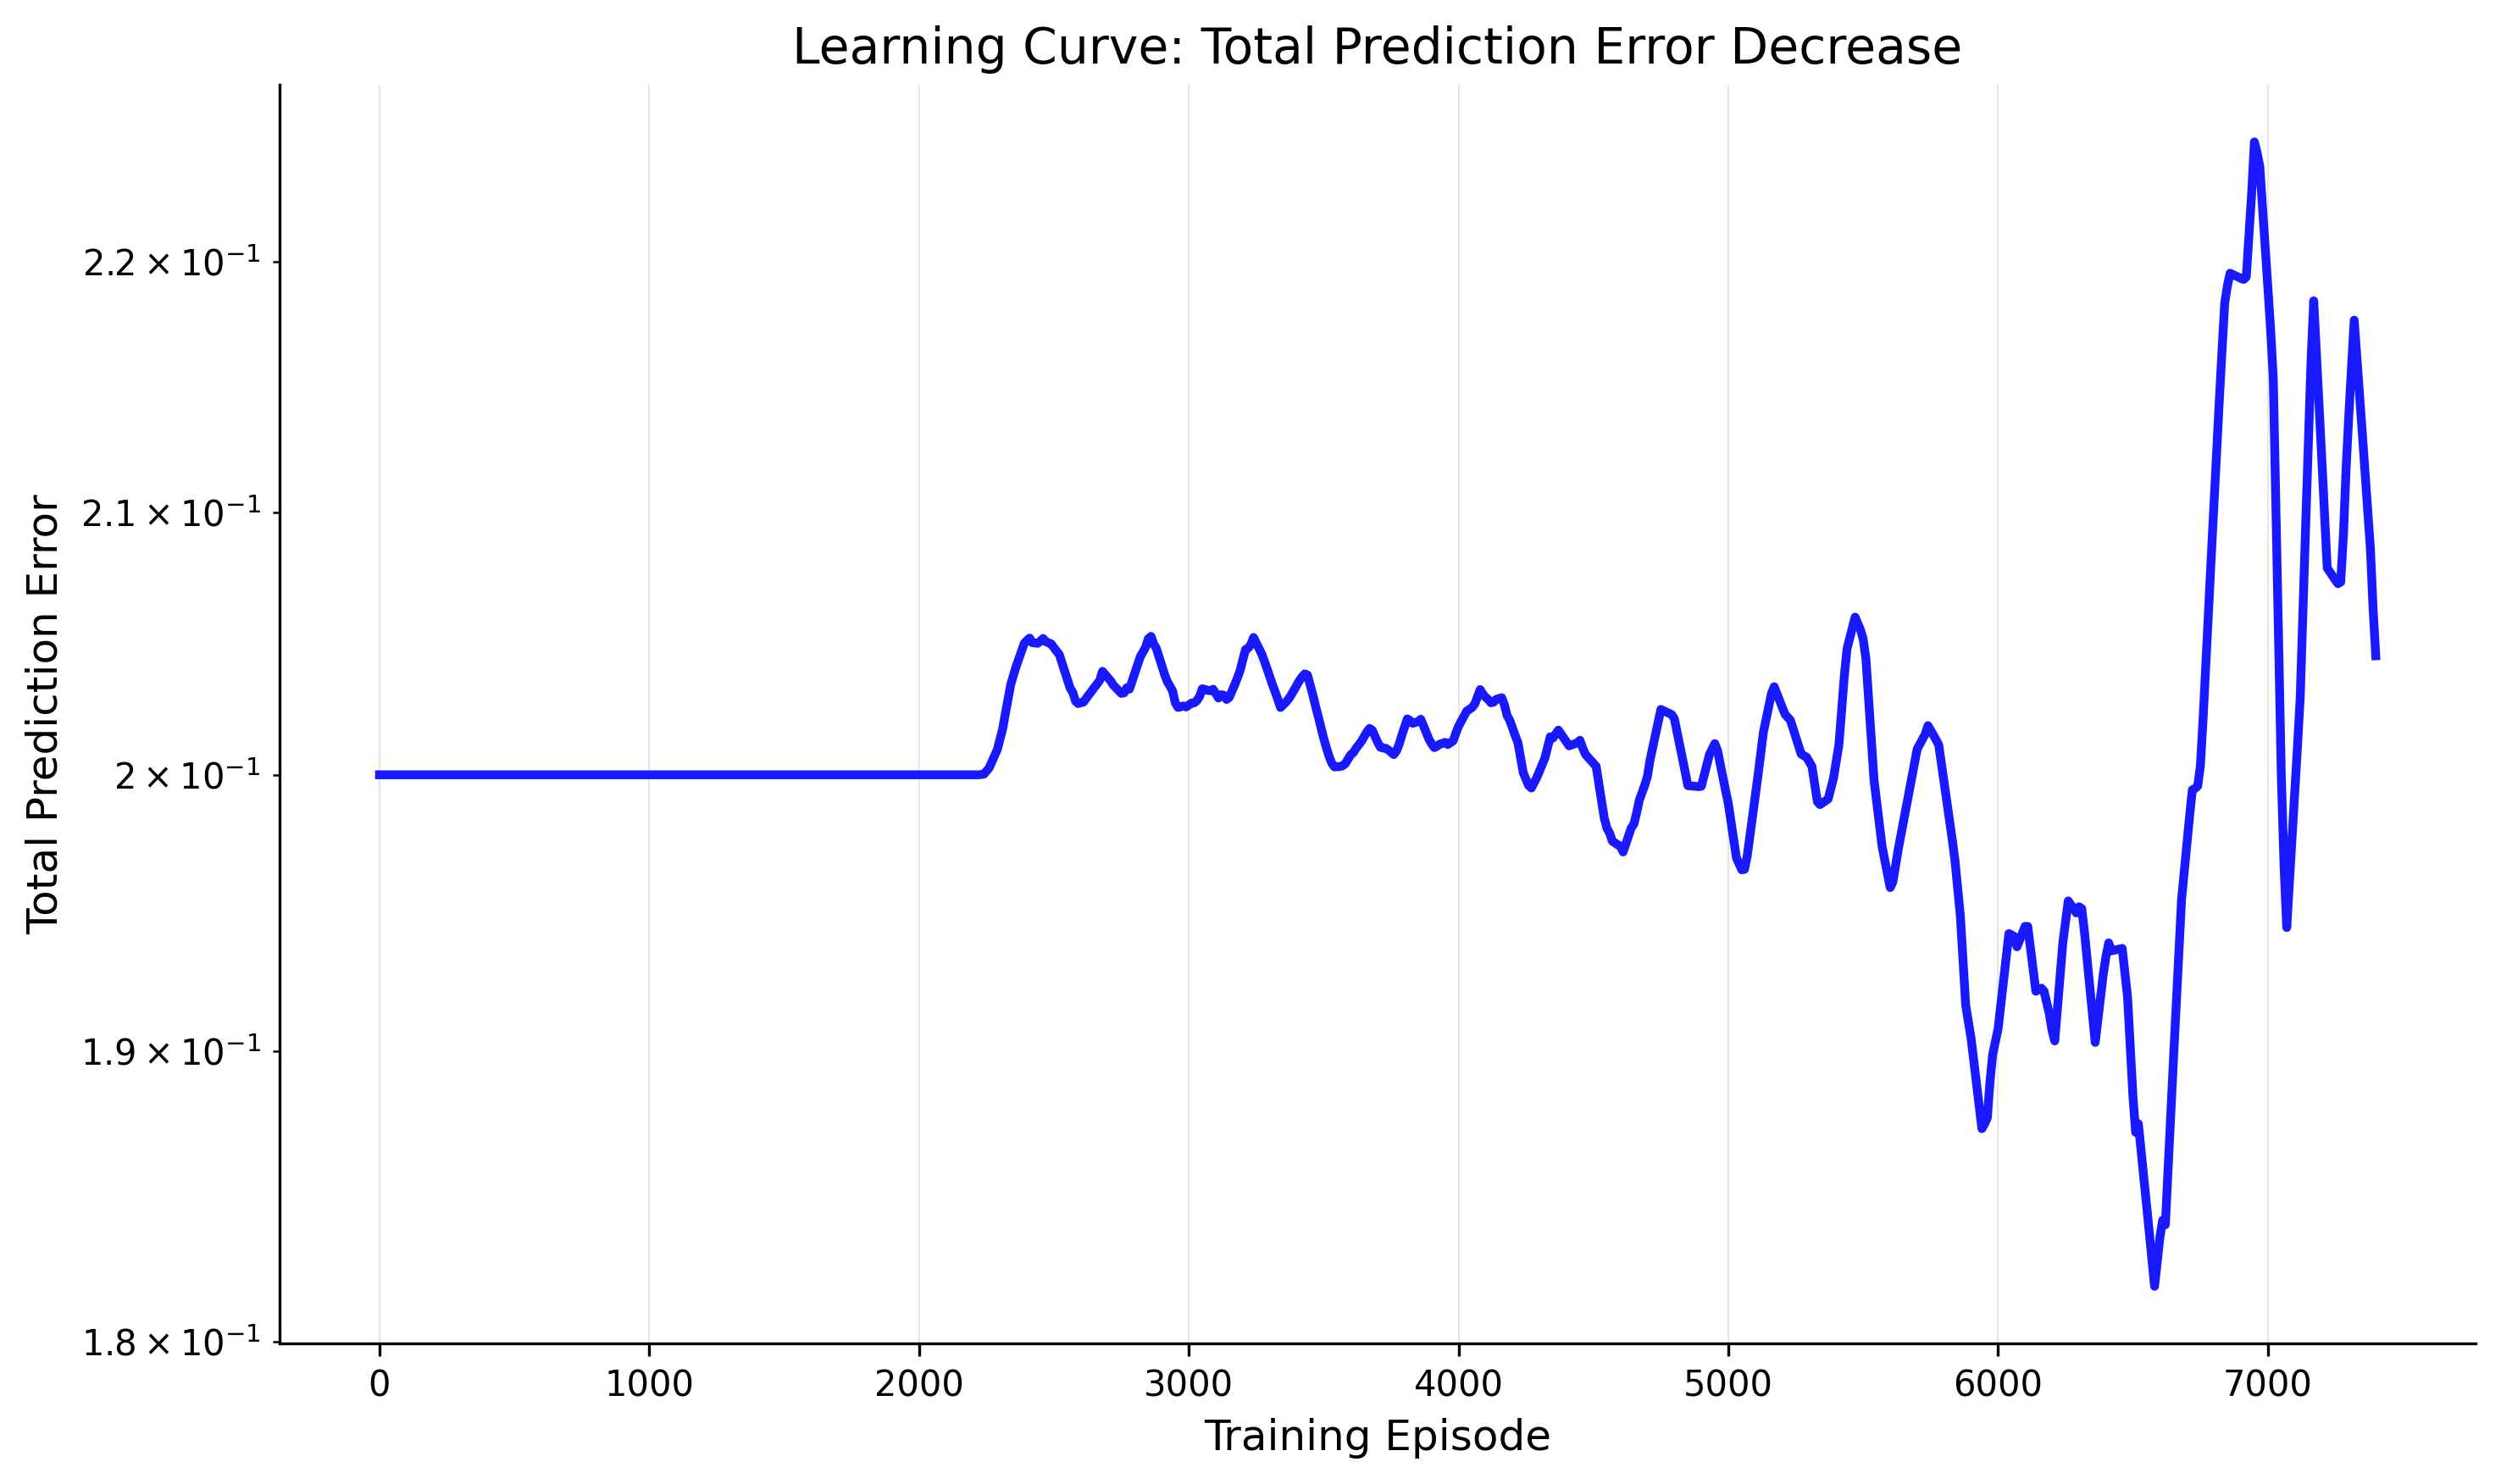

Training episodes: 741
Initial error: 0.200000
Final error: 0.201219
Error reduction: 1.0x


array([0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.2       , 0.2    

In [24]:
data = extract_tensorboard_data_api("/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/experiments/doublebeat/best_params_20250411_173008_trial_460_20250603_004022_20250606_003834_20250621_232236/logs/events.out.tfevents.1750562556.Mac.51823.0")

arr = np.array(data['beat_error']['values'][100:850]) + np.array(data['vest_error']['values'][100:850])
# arr = np.array(data['beat_error']['values'][:750])
# arr = np.array(data['vest_error']['values'][:750])
# arr = float_list[1:]
window = 10
ma = np.mean([arr[i:i+window] for i in range(len(arr) - window + 1)], axis=1)
# plt.plot(ma)

plot_figure4a_total_error(ma, smoothing_window=10, max_index=1000)


/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_10030/1082873446.py:45: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data[key] = np.array(pickle.load(f))


Detected 28 cycles, each 10 steps long
Showing cycles 0 to 5 (indices 0 to 59)


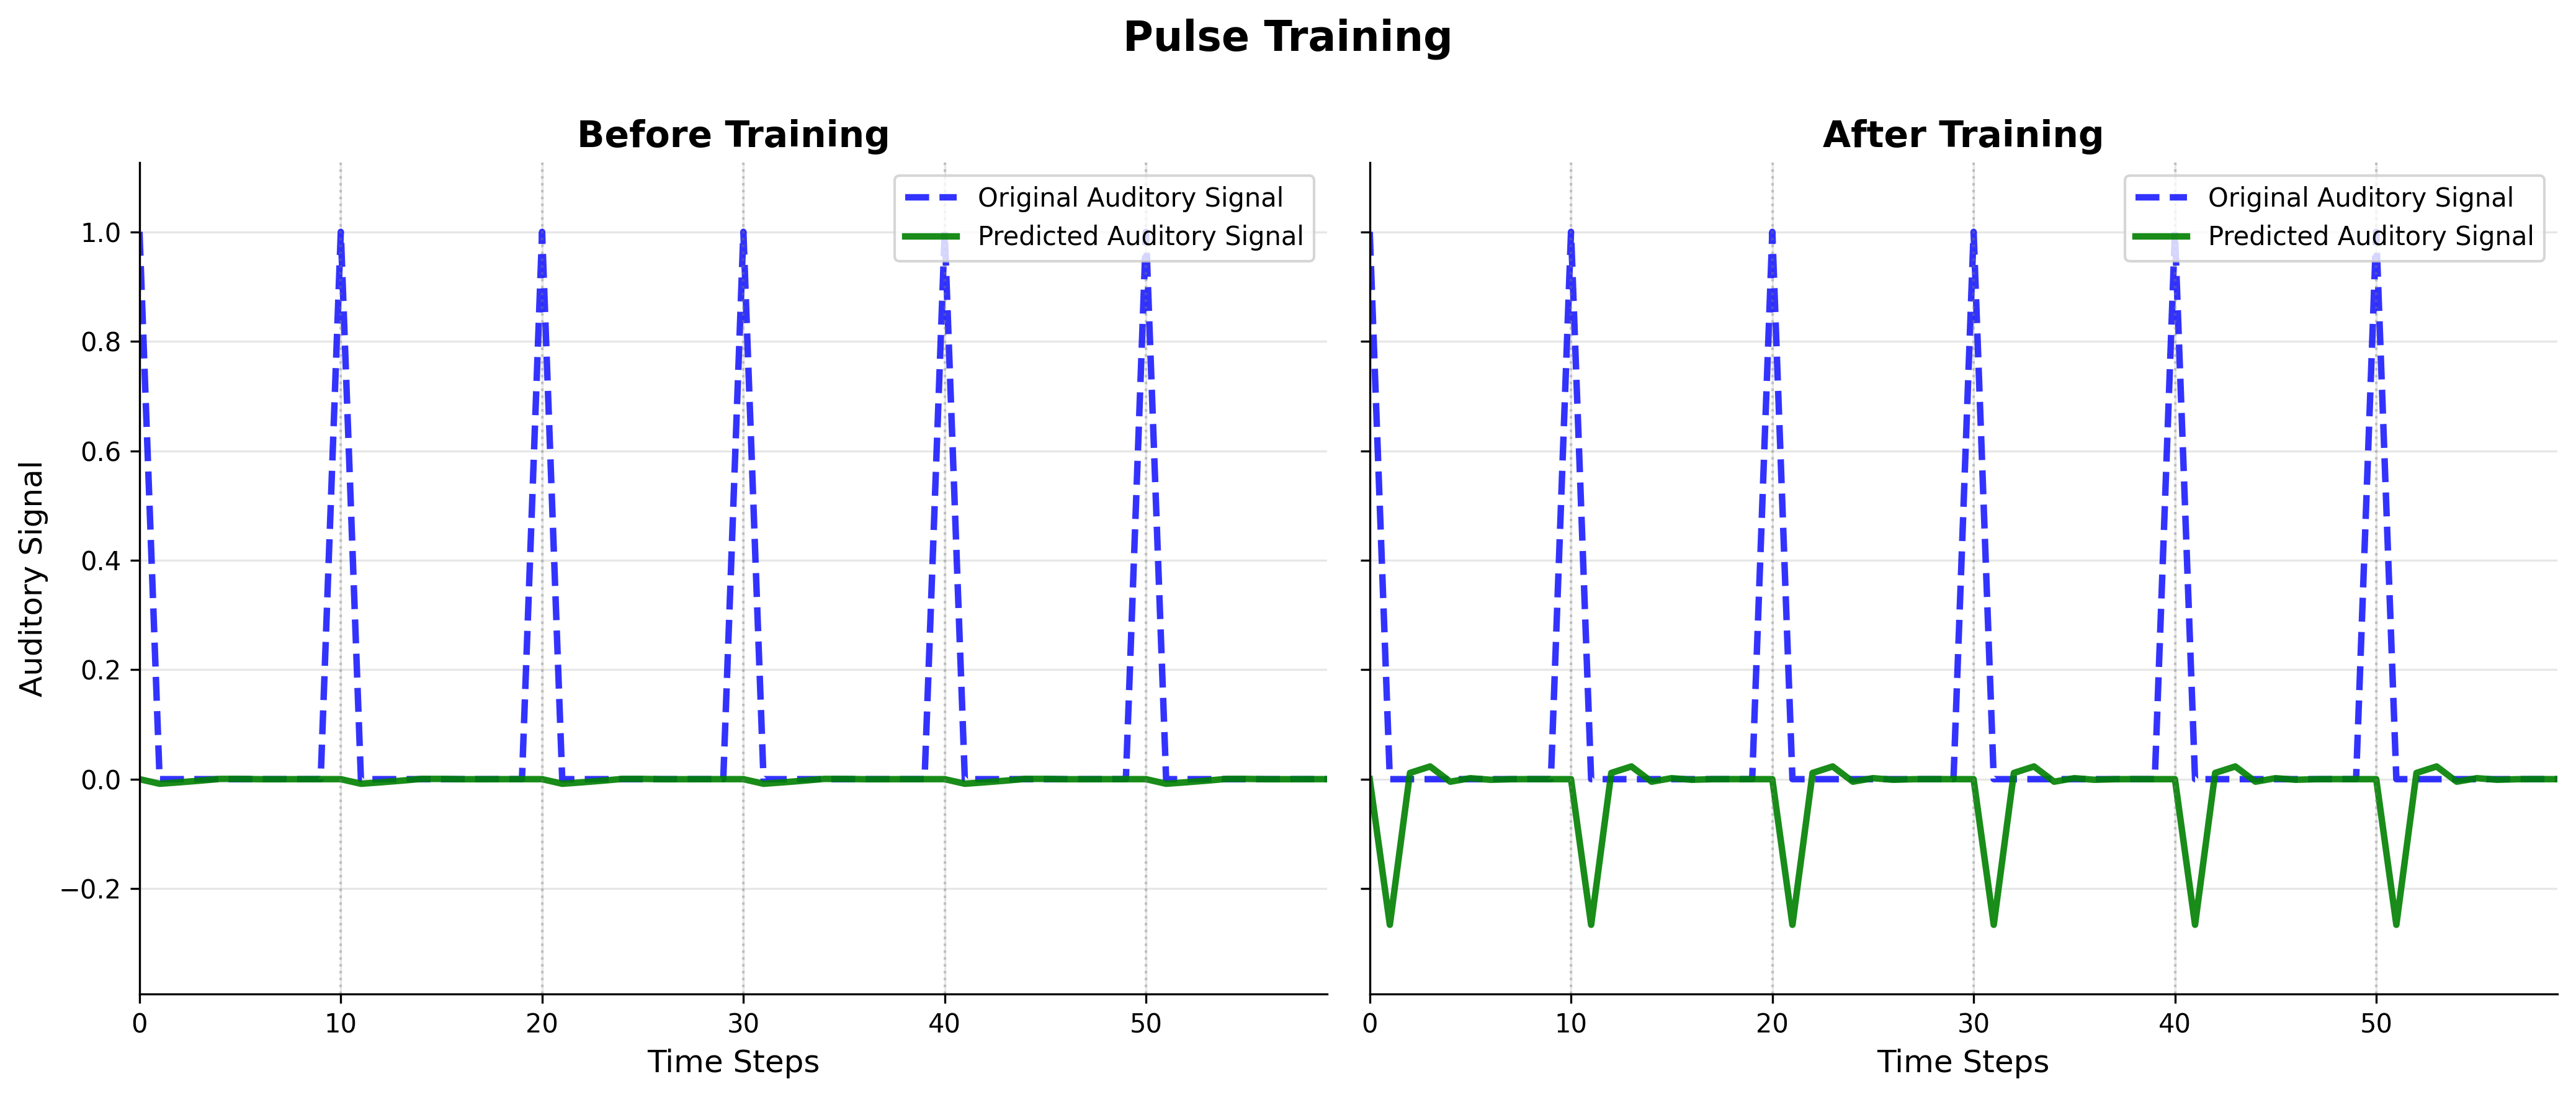

Learning Assessment:
  Cycles shown: 0 to 5
  Correlation between before/after predictions: 0.727
  Result: Some learning
  Conclusion: Vestibular scaffolding appears necessary for effective learning


In [29]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
   'font.size': 12,
   'axes.titlesize': 14,
   'axes.labelsize': 12,
   'xtick.labelsize': 10,
   'ytick.labelsize': 10,
   'legend.fontsize': 10,
   'figure.titlesize': 16,
   'lines.linewidth': 2,
   'figure.dpi': 300,
   'savefig.dpi': 300
})

def plot_figure4_double_auditory(start_cycle=0, end_cycle=4):
   """
   Plot Figure 4: Double auditory input condition showing failed learning
   Network receives only auditory input (no vestibular) during training
   Shows that vestibular scaffolding is necessary for learning
   
   Parameters:
   -----------
   start_cycle : int
       Starting cycle number (0-based)  
   end_cycle : int
       Ending cycle number (0-based)
   """
   
   # Load data files
   files = {
       'beat_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_before_double_auditory.pkl',
       'beat_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_after_double_auditory.pkl', 
       'beat_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_before_double_auditory.pkl',
       'beat_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_after_double_auditory.pkl'
   }
   
   data = {}
   for key, filename in files.items():
       with open(filename, 'rb') as f:
           data[key] = np.array(pickle.load(f))
   
   # Detect cycle boundaries from beat sequence
   beat_peaks = np.where(data['beat_seq_after'] > 0.5)[0]
   
   if len(beat_peaks) < 2:
       print("Error: Could not detect beat cycles!")
       return
   
   cycle_length = beat_peaks[1] - beat_peaks[0]
   total_cycles = len(beat_peaks)
   
   print(f"Detected {total_cycles} cycles, each {cycle_length} steps long")
   
   # Validate cycle range
   if start_cycle >= total_cycles or end_cycle > total_cycles:
       print(f"Error: Requested cycles {start_cycle}-{end_cycle} exceed available cycles (0-{total_cycles-1})")
       return
   
   # Calculate start and end indices
   start_idx = start_cycle * cycle_length
   end_idx = end_cycle * cycle_length
   
   print(f"Showing cycles {start_cycle} to {end_cycle-1} (indices {start_idx} to {end_idx-1})")
   
   # Extract the desired time window from all arrays
   for key in data:
       data[key] = data[key][start_idx:end_idx]
   
   time_steps = np.arange(len(data['beat_pred_before']))
   
   # Calculate y-axis limits to show all data
   beat_min = min(data['beat_seq_before'].min(), data['beat_seq_after'].min(), 
                  data['beat_pred_before'].min(), data['beat_pred_after'].min())
   beat_max = max(data['beat_seq_before'].max(), data['beat_seq_after'].max(), 
                  data['beat_pred_before'].max(), data['beat_pred_after'].max())
   beat_margin = (beat_max - beat_min) * 0.1
   beat_ylim = [beat_min - beat_margin, beat_max + beat_margin]
   
   # Create 1x2 subplot layout (side by side)
   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
   
   # BEFORE TRAINING (Left panel)
   ax1.plot(time_steps, data['beat_seq_before'], 'b--', linewidth=1.5, 
            label='Original Auditory Signal', alpha=0.8)
   ax1.plot(time_steps, data['beat_pred_before'], 'g-', linewidth=1.5, 
            label='Predicted Auditory Signal', alpha=0.9)
   ax1.set_title('Before Training', fontweight='bold')
   ax1.set_xlabel('Time Steps')
   ax1.set_ylabel('Auditory Signal')
   ax1.legend(loc="upper right")
   ax1.grid(True, alpha=0.3)
   ax1.set_ylim(beat_ylim)
   
   # AFTER TRAINING (Right panel)
   ax2.plot(time_steps, data['beat_seq_after'], 'b--', linewidth=1.5, 
            label='Original Auditory Signal', alpha=0.8)
   ax2.plot(time_steps, data['beat_pred_after'], 'g-', linewidth=1.5, 
            label='Predicted Auditory Signal', alpha=0.9)
   ax2.set_title('After Training', fontweight='bold')
   ax2.set_xlabel('Time Steps')
   ax2.legend(loc="upper right")
   ax2.grid(True, alpha=0.3)
   ax2.set_ylim(beat_ylim)
   
   # Set consistent x-axis limits
   for ax in [ax1, ax2]:
       ax.set_xlim(0, len(time_steps)-1)
   
   # Add vertical alignment lines at beat times
   beat_times_before = time_steps[data['beat_seq_before'] > 0.5]
   beat_times_after = time_steps[data['beat_seq_after'] > 0.5]
   
   for beat_time in beat_times_before:
       ax1.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
   
   for beat_time in beat_times_after:
       ax2.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
   
   # Add annotations to emphasize failed learning

   # ax2.text(0.5, 0.9, 'Learning Failed\n(No Improvement)', transform=ax2.transAxes, 
   #          ha='center', va='center', fontsize=11, style='italic',
   #          bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))
   
   
   # Remove top and right spines
   for ax in [ax1, ax2]:
       ax.spines['top'].set_visible(False)
       ax.spines['right'].set_visible(False)
   
   # Add overall figure labels
   # fig.text(0.25, 0.95, 'BEFORE TRAINING', ha='center', fontsize=16, fontweight='bold')
   # fig.text(0.75, 0.95, 'AFTER TRAINING', ha='center', fontsize=16, fontweight='bold')
   fig.text(0.5, 0.95, 'Pulse Training', ha='center', fontsize=16, fontweight='bold')
   
   # Add main title
   # fig.suptitle('Vestibular Scaffolding Necessary for Learning', 
   #              fontsize=18, fontweight='bold', y=0.98)
   
   plt.tight_layout()
   plt.subplots_adjust(top=0.85)  # Make room for titles
   plt.savefig(f'figure4_double_auditory_cycles{start_cycle}to{end_cycle-1}.png', 
               dpi=300, bbox_inches='tight', facecolor='white')
   plt.show()
   
   # Calculate and show similarity between before/after to demonstrate lack of learning
   before_pred = data['beat_pred_before']
   after_pred = data['beat_pred_after'] 
   correlation = np.corrcoef(before_pred, after_pred)[0, 1]
   
   print(f"Learning Assessment:")
   print(f"  Cycles shown: {start_cycle} to {end_cycle-1}")
   print(f"  Correlation between before/after predictions: {correlation:.3f}")
   print(f"  Result: {'Minimal learning' if correlation > 0.8 else 'Some learning' if correlation > 0.5 else 'Poor learning'}")
   print(f"  Conclusion: Vestibular scaffolding appears necessary for effective learning")

# Examples:
# Show first 4 cycles
plot_figure4_double_auditory(start_cycle=0, end_cycle=6)

# Show cycles 10-14 to compare with Figure 2
# plot_figure4_double_auditory(start_cycle=10, end_cycle=14)

/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_10030/655396804.py:41: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data[key] = np.array(pickle.load(f))


Vestibular y-limits: [np.float32(-1.2), np.float32(1.2)]
Beat y-limits: [np.float64(-0.33617745637893676), np.float64(1.1214706778526307)]
Auditory y-limits: [np.float64(-0.33617745637893676), np.float64(1.1214706778526307)]


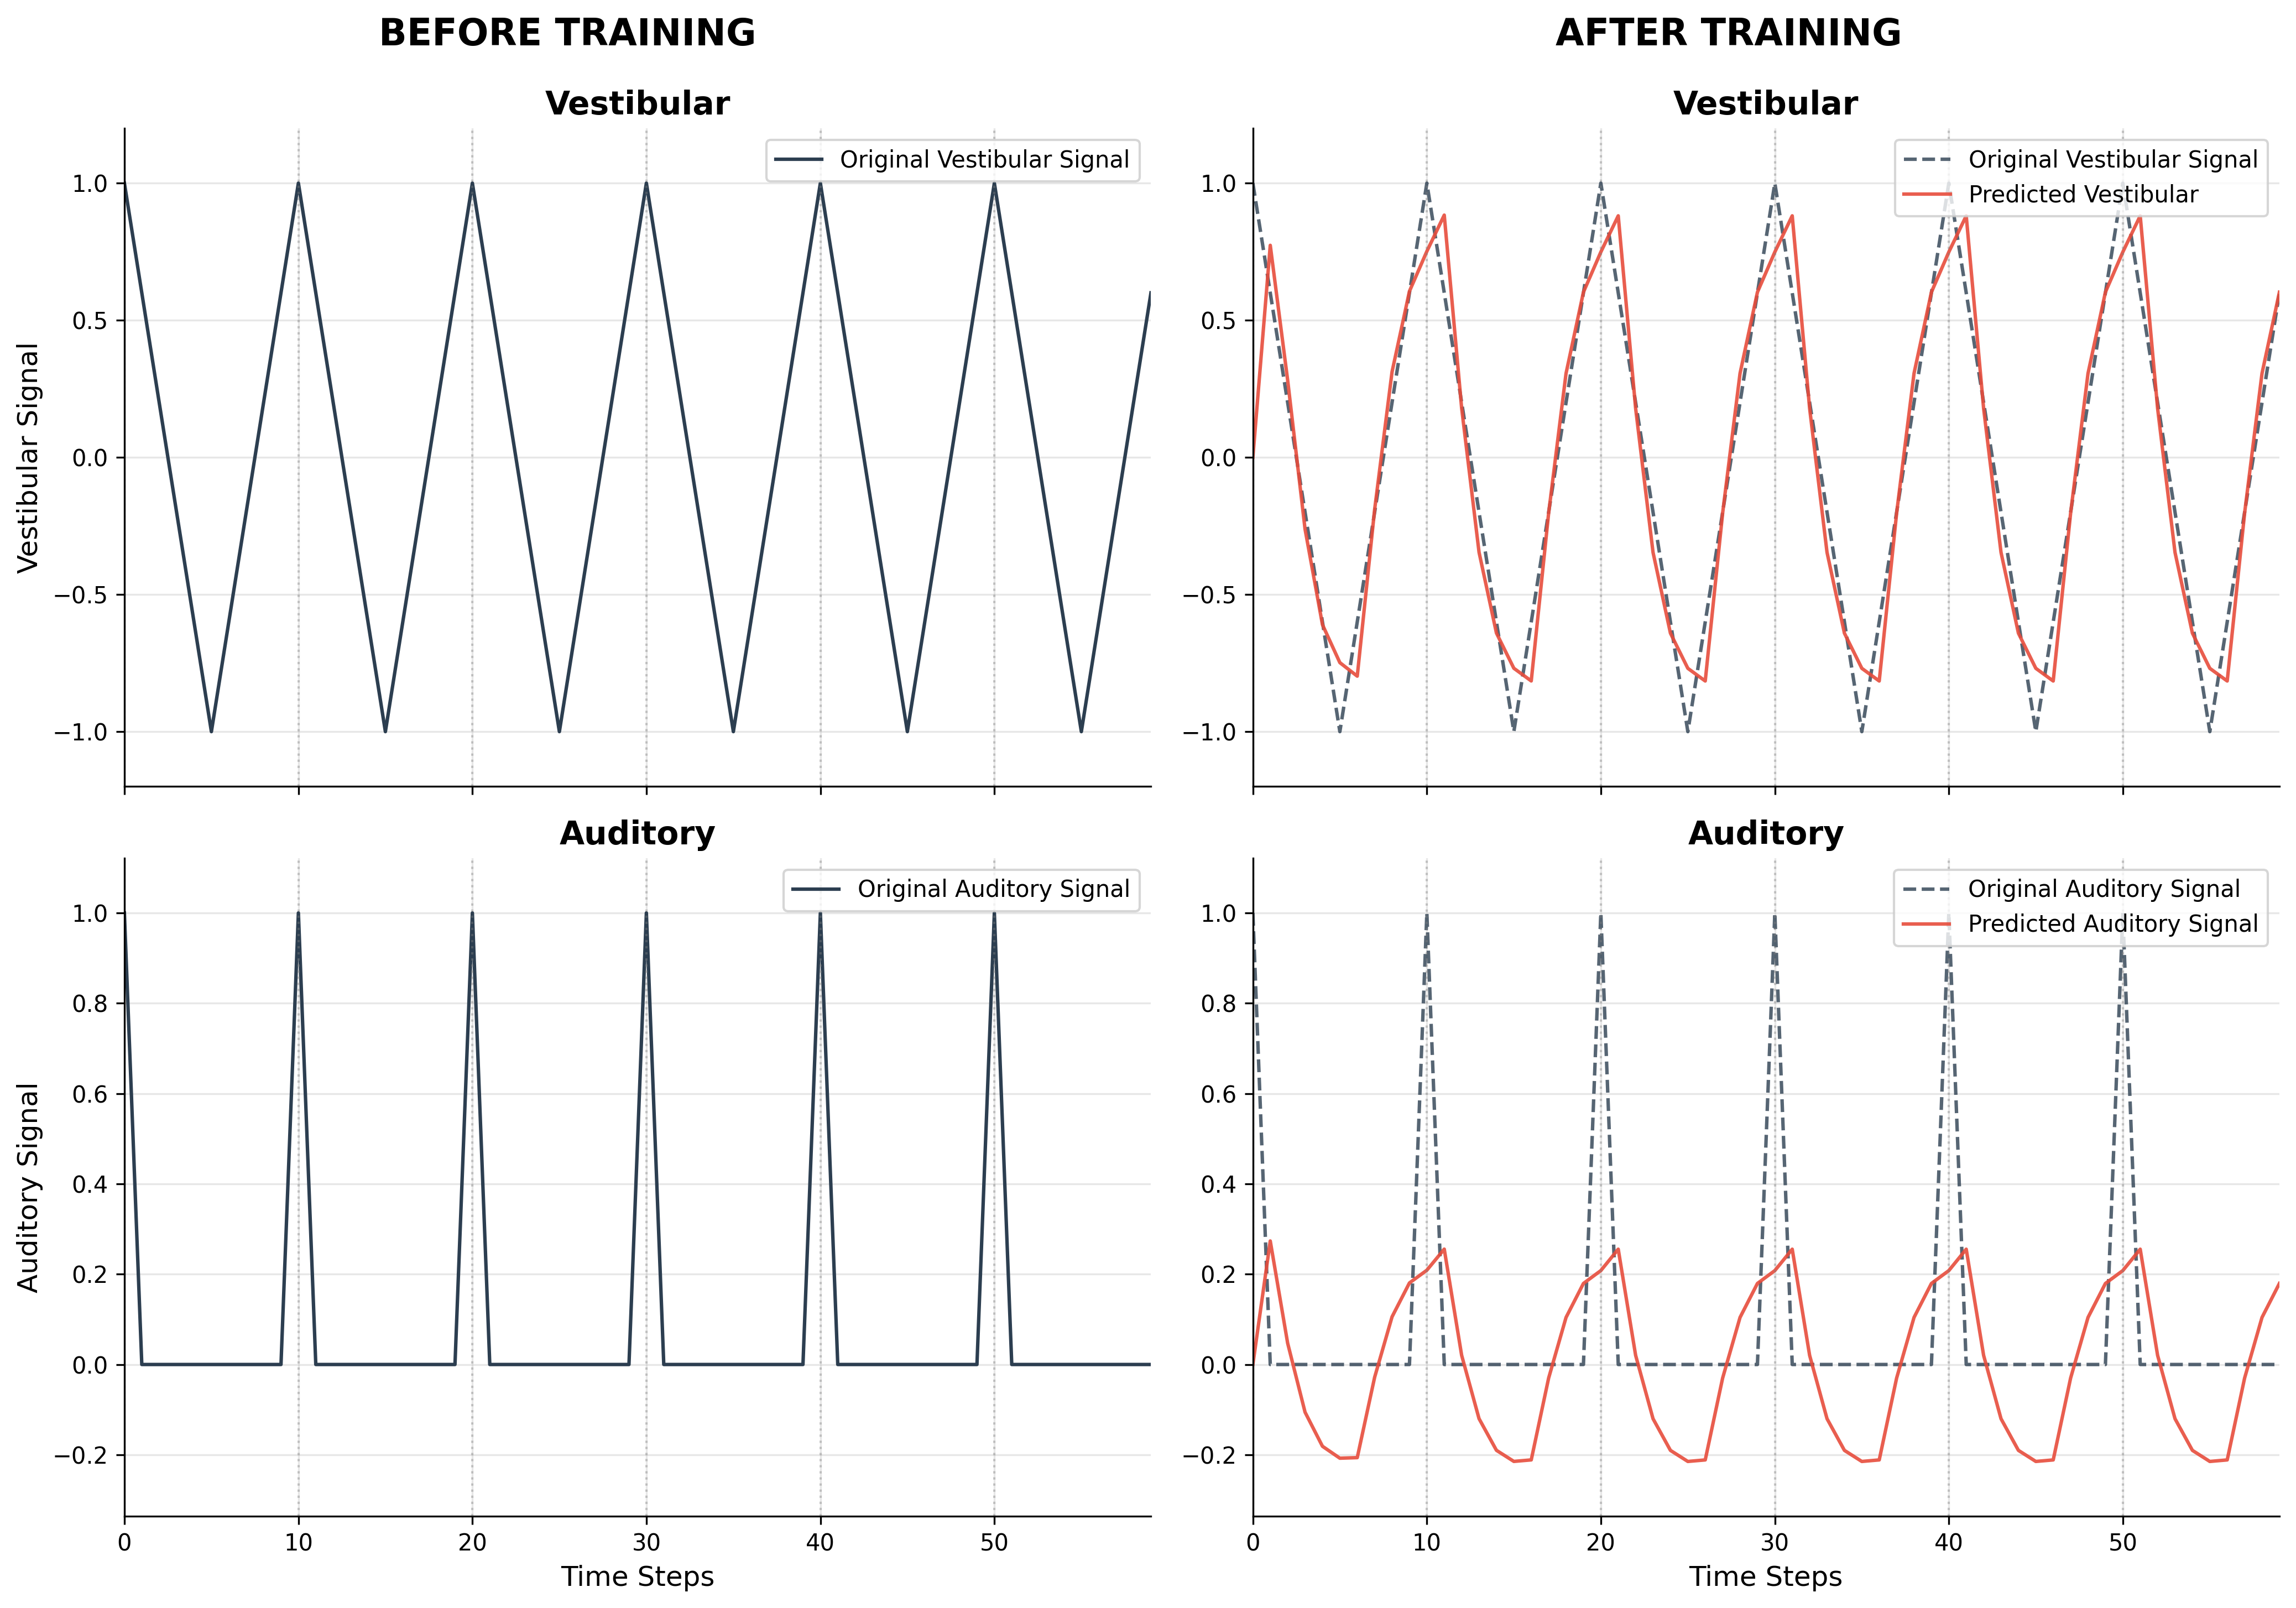

Showing 6 cycles (60 time steps)
Y-axis limits automatically adjusted to show ALL data values


In [34]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'lines.linewidth': 2,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

def plot_figure1b_before_after(max_cycles=4):
    """
    Plot Figure 1B: Before/After training comparison with 2x2 subplot layout
    Y-axis limits adjusted to show ALL data values (no vertical clipping)
    """
    
    # Load all data files
    files = {
       'beat_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_before.pkl',
       'beat_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_after.pkl', 
       'beat_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_before.pkl',
       'beat_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_after.pkl',
       'vest_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_before.pkl',
       'vest_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_after.pkl',
       'vest_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_before.pkl',
       'vest_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_after.pkl'
   }
    
    data = {}
    for key, filename in files.items():
        with open(filename, 'rb') as f:
            data[key] = np.array(pickle.load(f))
    
    # Find the minimum length across all arrays
    min_length = min([len(data[key]) for key in data.keys()])
    
    # Estimate cycle length and limit data
    beat_peaks = np.where(data['beat_seq_after'] > 0.5)[0]
    if len(beat_peaks) > 1:
        cycle_length = beat_peaks[1] - beat_peaks[0]
    else:
        cycle_length = 100
    
    max_points = min(max_cycles * cycle_length, min_length)
    
    # Apply same truncation to ALL arrays
    for key in data:
        data[key] = data[key][:max_points]
    
    time_steps = np.arange(max_points)
    
    # Calculate y-axis limits for each signal type to show ALL data
    vest_min = min(data['vest_seq_before'].min(), data['vest_seq_after'].min(), 
                   data['vest_pred_before'].min(), data['vest_pred_after'].min())
    vest_max = max(data['vest_seq_before'].max(), data['vest_seq_after'].max(), 
                   data['vest_pred_before'].max(), data['vest_pred_after'].max())
    vest_margin = (vest_max - vest_min) * 0.1  # 10% margin
    vest_ylim = [vest_min - vest_margin, vest_max + vest_margin]
    
    beat_min = min(data['beat_seq_before'].min(), data['beat_seq_after'].min(), 
                   data['beat_pred_before'].min(), data['beat_pred_after'].min())
    beat_max = max(data['beat_seq_before'].max(), data['beat_seq_after'].max(), 
                   data['beat_pred_before'].max(), data['beat_pred_after'].max())
    beat_margin = (beat_max - beat_min) * 0.1  # 10% margin
    beat_ylim = [beat_min - beat_margin, beat_max + beat_margin]
    
    print(f"Vestibular y-limits: {vest_ylim}")
    print(f"Beat y-limits: {beat_ylim}")
    
    print(f"Auditory y-limits: {beat_ylim}")
    
    # Professional color scheme
    actual_color = '#2C3E50'      # Dark blue-gray for actual/original signals
    predicted_color = '#E74C3C'   # Muted red for predicted signals
    
    # Create 2x2 subplot layout
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    
    # BEFORE TRAINING - VESTIBULAR (Top Left)
    ax1.plot(time_steps, data['vest_seq_before'], color=actual_color, linestyle='-', linewidth=1.5, 
             alpha=1, label='Original Vestibular Signal')
    # ax1.plot(time_steps, data['vest_pred_before'], color=predicted_color, linestyle='-', linewidth=1.5, 
    #          label='Predicted Vestibular', alpha=0.9)
    ax1.set_title('Vestibular', fontweight='bold')
    ax1.set_ylabel('Vestibular Signal')
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(vest_ylim)  # Dynamic y-limits
    
    # AFTER TRAINING - VESTIBULAR (Top Right)
    ax2.plot(time_steps, data['vest_seq_after'], color=actual_color, linestyle='--', linewidth=1.5, 
             alpha=0.8, label='Original Vestibular Signal')
    ax2.plot(time_steps, data['vest_pred_after'], color=predicted_color, linestyle='-', linewidth=1.5, 
             label='Predicted Vestibular', alpha=0.9)
    ax2.set_title('Vestibular', fontweight='bold')
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(vest_ylim)  # Same y-limits as left panel
    
    # BEFORE TRAINING - BEAT (Bottom Left)
    ax3.plot(time_steps, data['beat_seq_before'], color=actual_color, linestyle='-', linewidth=1.5, 
             label='Original Auditory Signal', alpha=1)
    # ax3.plot(time_steps, data['beat_pred_before'], color=predicted_color, linestyle='-', linewidth=1.5, 
    #          label='Predicted Auditory Signal', alpha=0.9)
    ax3.set_title('Auditory', fontweight='bold')
    ax3.set_xlabel('Time Steps')
    ax3.set_ylabel('Auditory Signal')
    ax3.legend(loc="upper right")
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(beat_ylim)  # Dynamic y-limits
    
    # AFTER TRAINING - BEAT (Bottom Right)
    ax4.plot(time_steps, data['beat_seq_after'], color=actual_color, linestyle='--', linewidth=1.5, 
             label='Original Auditory Signal', alpha=0.8)
    ax4.plot(time_steps, data['beat_pred_after'], color=predicted_color, linestyle='-', linewidth=1.5, 
             label='Predicted Auditory Signal', alpha=0.9)
    ax4.set_title('Auditory', fontweight='bold')
    ax4.set_xlabel('Time Steps')
    ax4.legend(loc="upper right")
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(beat_ylim)  # Same y-limits as left panel
    
    # Set consistent x-axis limits
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlim(0, max_points-1)
    
    # Add vertical alignment lines
    beat_times_before = time_steps[data['beat_seq_before'] > 0.5]
    beat_times_after = time_steps[data['beat_seq_after'] > 0.5]
    
    for beat_time in beat_times_before:
        ax1.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        ax3.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
    
    for beat_time in beat_times_after:
        ax2.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        ax4.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
    
    # Add annotati
    
    # Remove top and right spines
    for ax in [ax1, ax2, ax3, ax4]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Add overall figure labels
    fig.text(0.25, 0.95, 'BEFORE TRAINING', ha='center', fontsize=16, fontweight='bold')
    fig.text(0.75, 0.95, 'AFTER TRAINING', ha='center', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig(f'figure2_a&b_abstract_before_after_full_range_{max_cycles}cycles.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"Showing {max_cycles} cycles ({max_points} time steps)")
    print("Y-axis limits automatically adjusted to show ALL data values")

# Use it:
plot_figure1b_before_after(max_cycles=6)

/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_10030/1050087041.py:48: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data[key] = np.array(pickle.load(f))


Detected 40 cycles, each 10 steps long
Showing cycles 2 to 7 (indices 20 to 79)


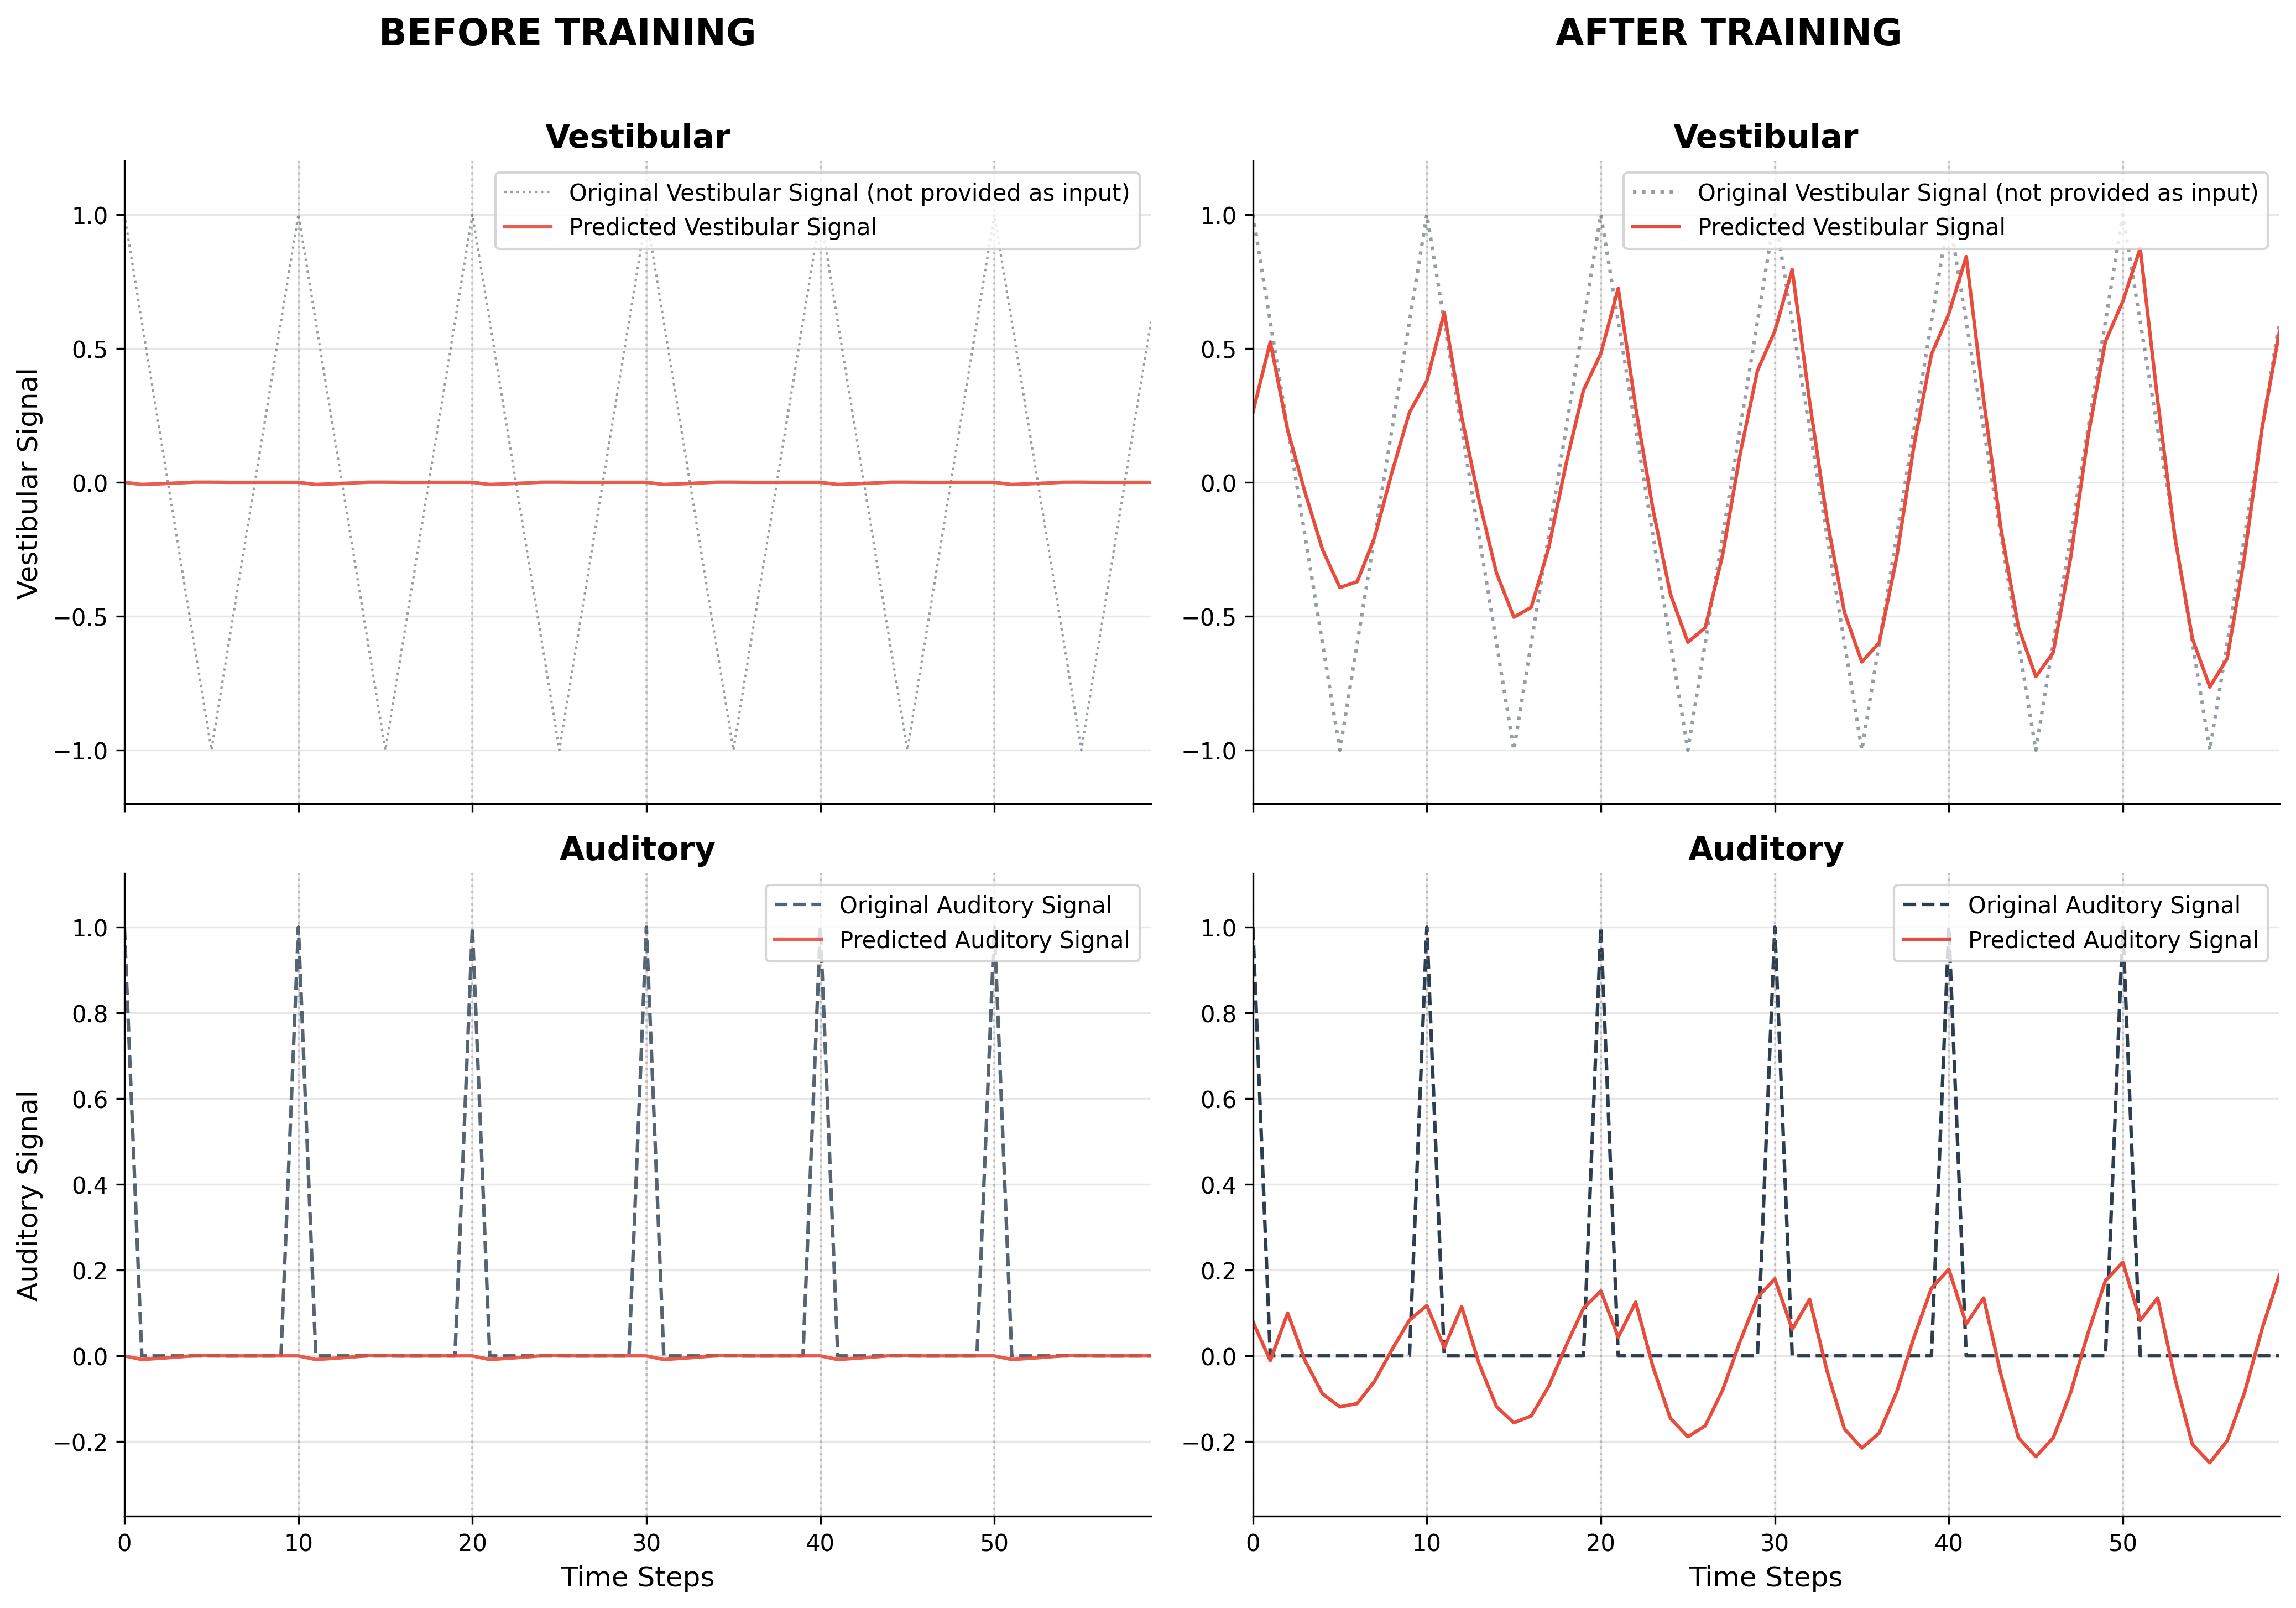

Showing cycles 2 to 7
Total time steps shown: 60


In [36]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
   'font.size': 12,
   'axes.titlesize': 14,
   'axes.labelsize': 12,
   'xtick.labelsize': 10,
   'ytick.labelsize': 10,
   'legend.fontsize': 10,
   'figure.titlesize': 16,
   'lines.linewidth': 2,
   'figure.dpi': 300,
   'savefig.dpi': 300
})

def plot_figure2_auditory_only(start_cycle=0, end_cycle=4):
   """
   Plot Figure 2: Auditory-only condition showing vestibular predictions from beat input
   Before/After comparison with auditory-only input (no vestibular input provided)
   
   Parameters:
   -----------
   start_cycle : int
       Starting cycle number (0-based)
   end_cycle : int
       Ending cycle number (0-based)
   """
   
   # Load all data files
   files = {
       'beat_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_before_auditory_rhythm.pkl',
       'beat_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_after_auditory_rhythm.pkl', 
       'beat_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_before_auditory_rhythm.pkl',
       'beat_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_after_auditory_rhythm.pkl',
       'vest_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_before_auditory_rhythm.pkl',
       'vest_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_after_auditory_rhythm.pkl',
       'vest_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_before_auditory_rhythm.pkl',
       'vest_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_after_auditory_rhythm.pkl'
   }
   
   data = {}
   for key, filename in files.items():
       with open(filename, 'rb') as f:
           data[key] = np.array(pickle.load(f))
   
   # Detect cycle boundaries from beat sequence
   beat_peaks = np.where(data['beat_seq_after'] > 0.5)[0]
   
   if len(beat_peaks) < 2:
       print("Error: Could not detect beat cycles!")
       return
   
   cycle_length = beat_peaks[1] - beat_peaks[0]
   total_cycles = len(beat_peaks)
   
   print(f"Detected {total_cycles} cycles, each {cycle_length} steps long")
   
   # Validate cycle range
   if start_cycle >= total_cycles or end_cycle > total_cycles:
       print(f"Error: Requested cycles {start_cycle}-{end_cycle} exceed available cycles (0-{total_cycles-1})")
       return
   
   if start_cycle >= end_cycle:
       print("Error: start_cycle must be less than end_cycle")
       return
   
   # Calculate start and end indices
   start_idx = start_cycle * cycle_length
   end_idx = end_cycle * cycle_length
   
   print(f"Showing cycles {start_cycle} to {end_cycle-1} (indices {start_idx} to {end_idx-1})")
   
   # Extract the desired time window from all arrays
   for key in data:
       data[key] = data[key][start_idx:end_idx]
   
   time_steps = np.arange(len(data['vest_pred_before']))
   
   # Calculate y-axis limits to show all data
   vest_min = min(data['vest_seq_before'].min(), data['vest_seq_after'].min(), 
                  data['vest_pred_before'].min(), data['vest_pred_after'].min())
   vest_max = max(data['vest_seq_before'].max(), data['vest_seq_after'].max(), 
                  data['vest_pred_before'].max(), data['vest_pred_after'].max())
   vest_margin = (vest_max - vest_min) * 0.1
   vest_ylim = [vest_min - vest_margin, vest_max + vest_margin]
   
   beat_min = min(data['beat_seq_before'].min(), data['beat_seq_after'].min(), 
                  data['beat_pred_before'].min(), data['beat_pred_after'].min())
   beat_max = max(data['beat_seq_before'].max(), data['beat_seq_after'].max(), 
                  data['beat_pred_before'].max(), data['beat_pred_after'].max())
   beat_margin = (beat_max - beat_min) * 0.1
   beat_ylim = [beat_min - beat_margin, beat_max + beat_margin]
   
   # Professional color scheme
   actual_color = '#2C3E50'      # Dark blue-gray for actual/original signals
   predicted_color = '#E74C3C'   # Muted red for predicted signals
   
   # Create 2x2 subplot layout
   fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
   
   # BEFORE TRAINING - VESTIBULAR (Top Left)
   ax1.plot(time_steps, data['vest_seq_before'], color=actual_color, linestyle=':', linewidth=1, 
            alpha=0.5, label='Original Vestibular Signal (not provided as input)')
   ax1.plot(time_steps, data['vest_pred_before'], color=predicted_color, linestyle='-', linewidth=1.5, 
            label='Predicted Vestibular Signal', alpha=0.9)
   ax1.set_title('Vestibular', fontweight='bold')
   ax1.set_ylabel('Vestibular Signal')
   ax1.legend(loc="upper right")
   ax1.grid(True, alpha=0.3)
   ax1.set_ylim(vest_ylim)
   
   # AFTER TRAINING - VESTIBULAR (Top Right)
   ax2.plot(time_steps, data['vest_seq_after'], color=actual_color, linestyle=':', linewidth=1.5, 
            alpha=0.5, label='Original Vestibular Signal (not provided as input)')
   ax2.plot(time_steps, data['vest_pred_after'], color=predicted_color, linestyle='-', linewidth=1.5, 
            label='Predicted Vestibular Signal', alpha=1)
   ax2.set_title('Vestibular', fontweight='bold')
   ax2.legend(loc="upper right")
   ax2.grid(True, alpha=0.3)
   ax2.set_ylim(vest_ylim)
   
   # BEFORE TRAINING - BEAT (Bottom Left)
   ax3.plot(time_steps, data['beat_seq_before'], color=actual_color, linestyle='--', linewidth=1.5, 
            label='Original Auditory Signal', alpha=0.8)
   ax3.plot(time_steps, data['beat_pred_before'], color=predicted_color, linestyle='-', linewidth=1.5, 
            label='Predicted Auditory Signal', alpha=0.9)
   ax3.set_title('Auditory', fontweight='bold')
   ax3.set_xlabel('Time Steps')
   ax3.set_ylabel('Auditory Signal')
   ax3.legend(loc="upper right")
   ax3.grid(True, alpha=0.3)
   ax3.set_ylim(beat_ylim)
   
   # AFTER TRAINING - BEAT (Bottom Right)
   ax4.plot(time_steps, data['beat_seq_after'], color=actual_color, linestyle='--', linewidth=1.5, 
            label='Original Auditory Signal', alpha=1)
   ax4.plot(time_steps, data['beat_pred_after'], color=predicted_color, linestyle='-', linewidth=1.5, 
            label='Predicted Auditory Signal', alpha=1)
   ax4.set_title('Auditory', fontweight='bold')
   ax4.set_xlabel('Time Steps')
   ax4.legend(loc="upper right")
   ax4.grid(True, alpha=0.3)
   ax4.set_ylim(beat_ylim)
   
   # Set consistent x-axis limits
   for ax in [ax1, ax2, ax3, ax4]:
       ax.set_xlim(0, len(time_steps)-1)
   
   # Add vertical alignment lines at beat times
   beat_times_before = time_steps[data['beat_seq_before'] > 0.5]
   beat_times_after = time_steps[data['beat_seq_after'] > 0.5]
   
   for beat_time in beat_times_before:
       ax1.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
       ax3.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
   
   for beat_time in beat_times_after:
       ax2.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
       ax4.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)

   
   # Remove top and right spines
   for ax in [ax1, ax2, ax3, ax4]:
       ax.spines['top'].set_visible(False)
       ax.spines['right'].set_visible(False)
   
   # Add overall figure labels
   fig.text(0.25, 0.95, 'BEFORE TRAINING', ha='center', fontsize=16, fontweight='bold')
   fig.text(0.75, 0.95, 'AFTER TRAINING', ha='center', fontsize=16, fontweight='bold')
   
   # Add main title with cycle info
   # fig.suptitle(f'Auditory-Only Input: Cycles {start_cycle}-{end_cycle-1}', 
   #              fontsize=18, fontweight='bold', y=0.98)
   
   plt.tight_layout()
   plt.subplots_adjust(top=0.88)
   plt.savefig(f'figure2_c_abstract_auditory_only_cycles{start_cycle}to{end_cycle-1}.png', 
               dpi=300, bbox_inches='tight', facecolor='white')
   plt.show()
   
   print(f"Showing cycles {start_cycle} to {end_cycle-1}")
   print(f"Total time steps shown: {len(time_steps)}")

# Examples:
# Show cycles 0-4 (first 4 cycles)
plot_figure2_auditory_only(start_cycle=2, end_cycle=8)

# Show cycles 10-14 (as you requested)
# plot_figure2_auditory_only(start_cycle=10, end_cycle=14)

# Show cycles 5-8
# plot_figure2_auditory_only(start_cycle=5, end_cycle=8)

/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_13057/338148192.py:46: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data_ab[key] = np.array(pickle.load(f))
/var/folders/vv/b6rpzr095z7842q169qx67ym0000gn/T/ipykernel_13057/338148192.py:78: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data_c[key] = np.array(pickle.load(f))


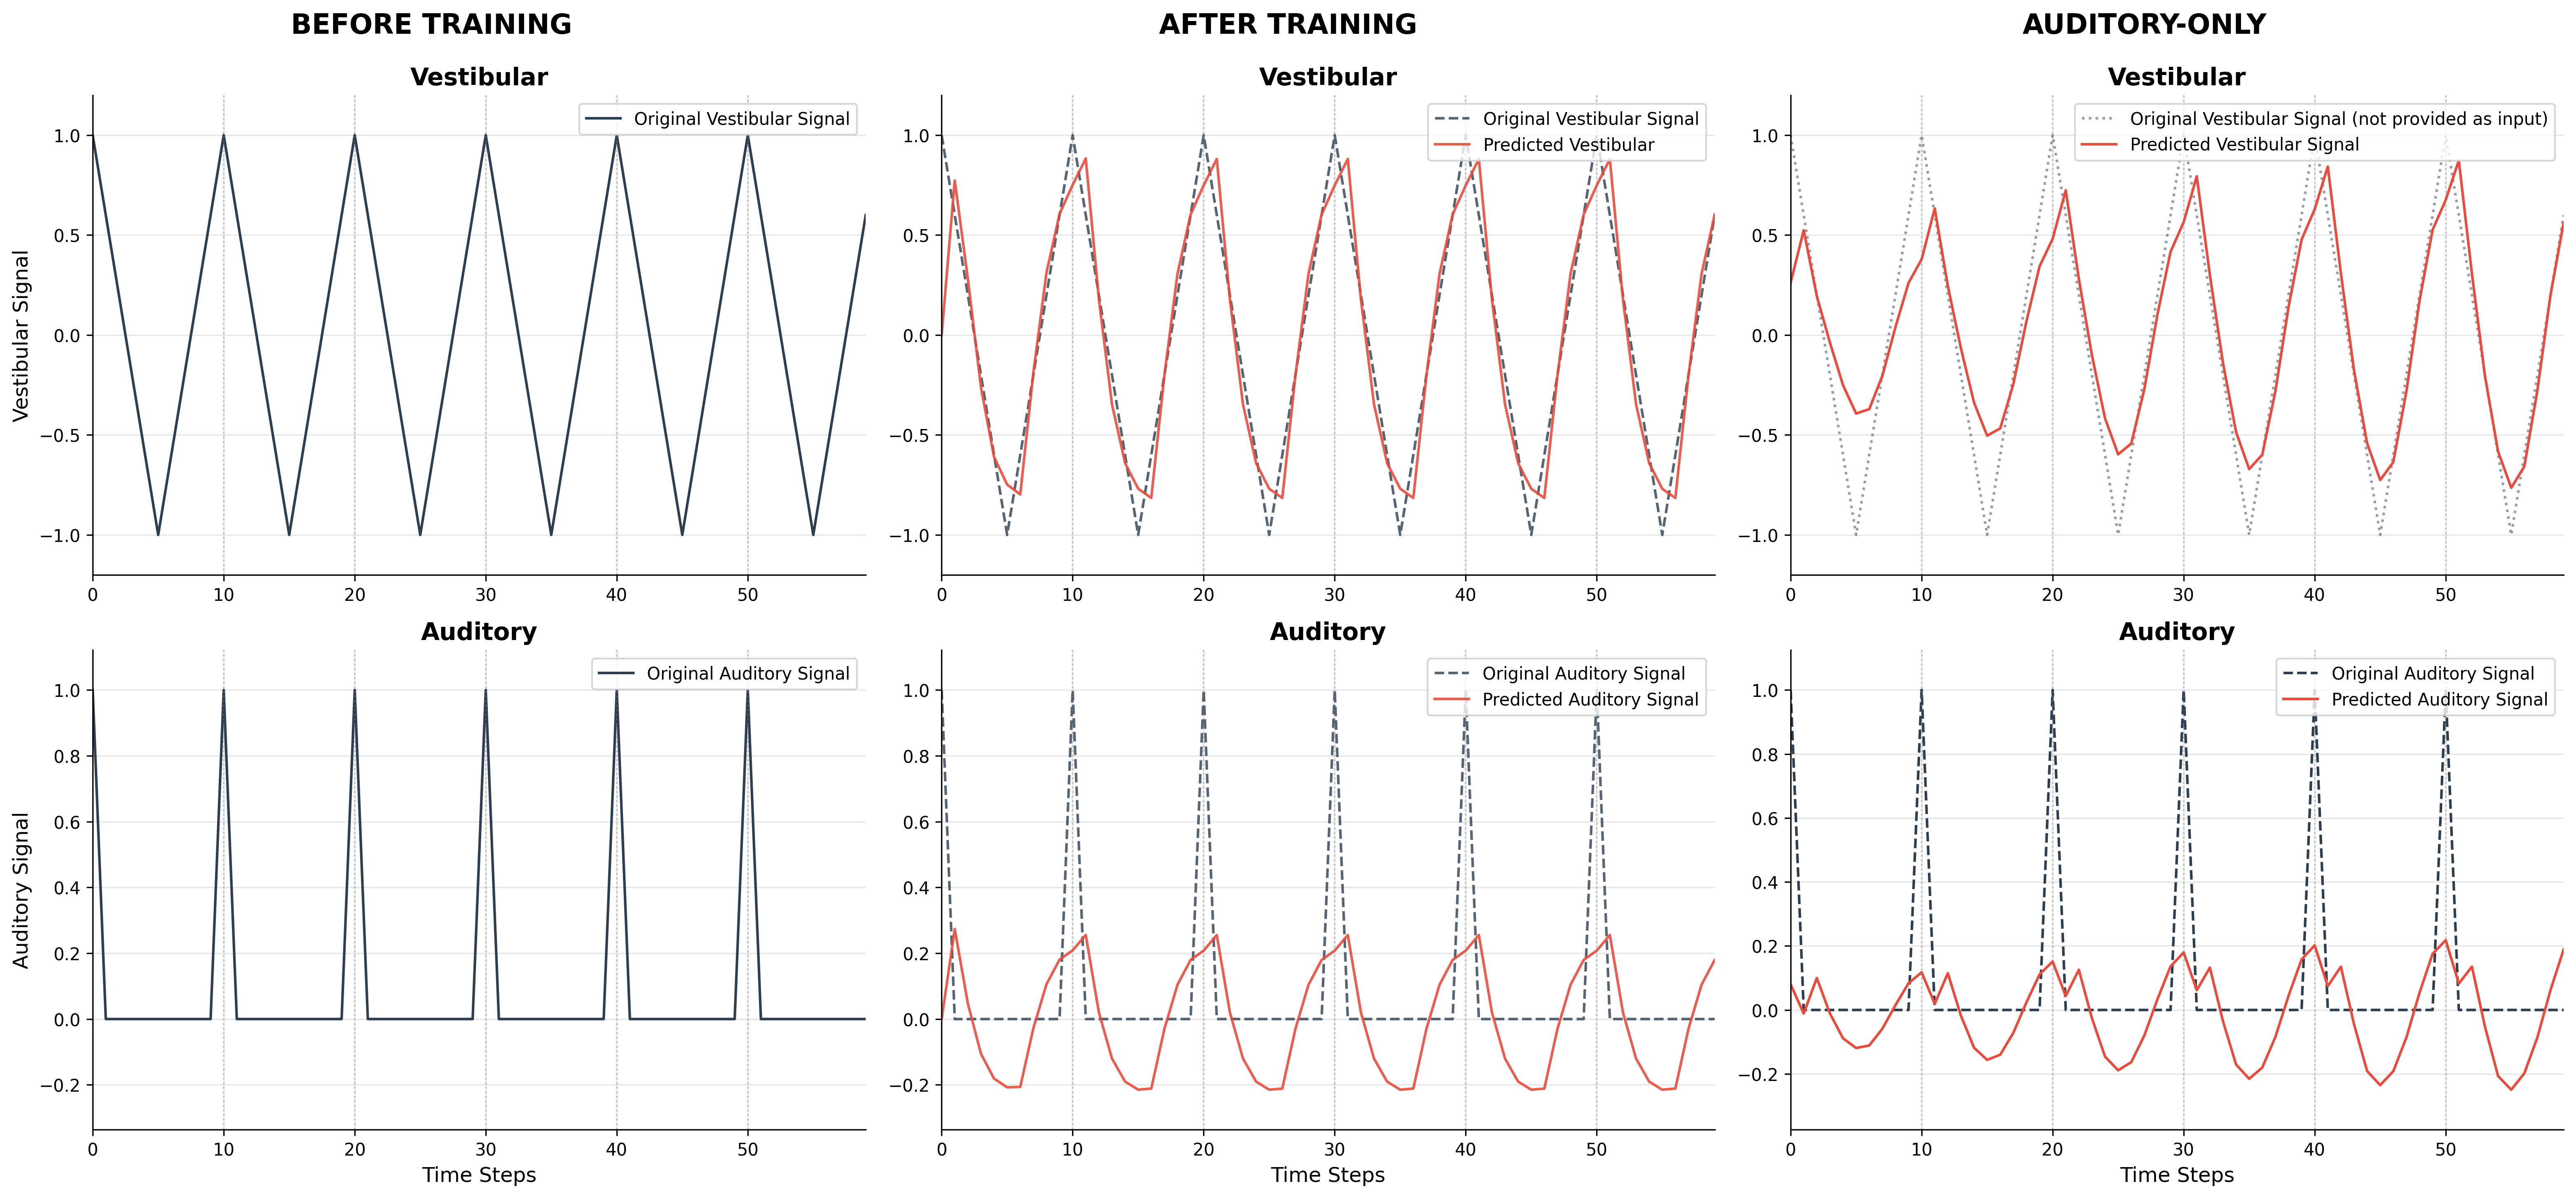

Combined figure: A&B showing 6 cycles, C showing cycles 2 to 7


In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'lines.linewidth': 2,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

def plot_combined_figure(max_cycles=6, start_cycle=2, end_cycle=8):
    """
    Combined plot with 2x3 layout:
    - First 4 axes (2x2): from a&b code (before/after training)
    - Last 2 axes (positions 2,4): from c code (auditory-only condition)
    """
    
    # Professional color scheme
    actual_color = '#2C3E50'      # Dark blue-gray for actual/original signals
    predicted_color = '#E74C3C'   # Muted red for predicted signals
    
    # Load data for a&b (first code)
    files_ab = {
       'beat_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_before.pkl',
       'beat_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_after.pkl', 
       'beat_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_before.pkl',
       'beat_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_after.pkl',
       'vest_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_before.pkl',
       'vest_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_after.pkl',
       'vest_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_before.pkl',
       'vest_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_after.pkl'
    }
    
    data_ab = {}
    for key, filename in files_ab.items():
        with open(filename, 'rb') as f:
            data_ab[key] = np.array(pickle.load(f))
    
    # Process a&b data
    min_length_ab = min([len(data_ab[key]) for key in data_ab.keys()])
    beat_peaks_ab = np.where(data_ab['beat_seq_after'] > 0.5)[0]
    if len(beat_peaks_ab) > 1:
        cycle_length_ab = beat_peaks_ab[1] - beat_peaks_ab[0]
    else:
        cycle_length_ab = 100
    
    max_points_ab = min(max_cycles * cycle_length_ab, min_length_ab)
    
    for key in data_ab:
        data_ab[key] = data_ab[key][:max_points_ab]
    
    time_steps_ab = np.arange(max_points_ab)
    
    # Load data for c (second code)
    files_c = {
       'beat_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_before_auditory_rhythm.pkl',
       'beat_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_pred_after_auditory_rhythm.pkl', 
       'beat_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_before_auditory_rhythm.pkl',
       'beat_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/beat_seq_after_auditory_rhythm.pkl',
       'vest_pred_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_before_auditory_rhythm.pkl',
       'vest_pred_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_pred_after_auditory_rhythm.pkl',
       'vest_seq_before': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_before_auditory_rhythm.pkl',
       'vest_seq_after': '/Users/matin/mcmaster/cannonlab/phd_codes/predictive_coding/rhythmic_pc_rnn/vest_seq_after_auditory_rhythm.pkl'
    }
    
    data_c = {}
    for key, filename in files_c.items():
        with open(filename, 'rb') as f:
            data_c[key] = np.array(pickle.load(f))
    
    # Process c data
    beat_peaks_c = np.where(data_c['beat_seq_after'] > 0.5)[0]
    if len(beat_peaks_c) < 2:
        print("Error: Could not detect beat cycles!")
        return
    
    cycle_length_c = beat_peaks_c[1] - beat_peaks_c[0]
    total_cycles_c = len(beat_peaks_c)
    
    if start_cycle >= total_cycles_c or end_cycle > total_cycles_c:
        print(f"Error: Requested cycles {start_cycle}-{end_cycle} exceed available cycles (0-{total_cycles_c-1})")
        return
    
    start_idx = start_cycle * cycle_length_c
    end_idx = end_cycle * cycle_length_c
    
    for key in data_c:
        data_c[key] = data_c[key][start_idx:end_idx]
    
    time_steps_c = np.arange(len(data_c['vest_pred_before']))
    
    # Calculate y-axis limits for each signal type
    vest_min_ab = min(data_ab['vest_seq_before'].min(), data_ab['vest_seq_after'].min(), 
                      data_ab['vest_pred_before'].min(), data_ab['vest_pred_after'].min())
    vest_max_ab = max(data_ab['vest_seq_before'].max(), data_ab['vest_seq_after'].max(), 
                      data_ab['vest_pred_before'].max(), data_ab['vest_pred_after'].max())
    vest_margin_ab = (vest_max_ab - vest_min_ab) * 0.1
    vest_ylim_ab = [vest_min_ab - vest_margin_ab, vest_max_ab + vest_margin_ab]
    
    beat_min_ab = min(data_ab['beat_seq_before'].min(), data_ab['beat_seq_after'].min(), 
                      data_ab['beat_pred_before'].min(), data_ab['beat_pred_after'].min())
    beat_max_ab = max(data_ab['beat_seq_before'].max(), data_ab['beat_seq_after'].max(), 
                      data_ab['beat_pred_before'].max(), data_ab['beat_pred_after'].max())
    beat_margin_ab = (beat_max_ab - beat_min_ab) * 0.1
    beat_ylim_ab = [beat_min_ab - beat_margin_ab, beat_max_ab + beat_margin_ab]
    
    vest_min_c = min(data_c['vest_seq_before'].min(), data_c['vest_seq_after'].min(), 
                     data_c['vest_pred_before'].min(), data_c['vest_pred_after'].min())
    vest_max_c = max(data_c['vest_seq_before'].max(), data_c['vest_seq_after'].max(), 
                     data_c['vest_pred_before'].max(), data_c['vest_pred_after'].max())
    vest_margin_c = (vest_max_c - vest_min_c) * 0.1
    vest_ylim_c = [vest_min_c - vest_margin_c, vest_max_c + vest_margin_c]
    
    beat_min_c = min(data_c['beat_seq_before'].min(), data_c['beat_seq_after'].min(), 
                     data_c['beat_pred_before'].min(), data_c['beat_pred_after'].min())
    beat_max_c = max(data_c['beat_seq_before'].max(), data_c['beat_seq_after'].max(), 
                     data_c['beat_pred_before'].max(), data_c['beat_pred_after'].max())
    beat_margin_c = (beat_max_c - beat_min_c) * 0.1
    beat_ylim_c = [beat_min_c - beat_margin_c, beat_max_c + beat_margin_c]
    
    # Create 2x3 subplot layout
    fig, axes = plt.subplots(2, 3, figsize=(21, 10))
    ax1, ax2, ax3 = axes[0]  # Top row
    ax4, ax5, ax6 = axes[1]  # Bottom row
    
    # A&B BEFORE TRAINING - VESTIBULAR (Position 1)
    ax1.plot(time_steps_ab, data_ab['vest_seq_before'], color=actual_color, linestyle='-', linewidth=1.5, 
             alpha=1, label='Original Vestibular Signal')
    ax1.set_title('Vestibular', fontweight='bold')
    ax1.set_ylabel('Vestibular Signal')
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(vest_ylim_ab)
    
    # A&B AFTER TRAINING - VESTIBULAR (Position 2)
    ax2.plot(time_steps_ab, data_ab['vest_seq_after'], color=actual_color, linestyle='--', linewidth=1.5, 
             alpha=0.8, label='Original Vestibular Signal')
    ax2.plot(time_steps_ab, data_ab['vest_pred_after'], color=predicted_color, linestyle='-', linewidth=1.5, 
             label='Predicted Vestibular', alpha=0.9)
    ax2.set_title('Vestibular', fontweight='bold')
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(vest_ylim_ab)
    
    # C AFTER TRAINING - VESTIBULAR (Position 3)
    ax3.plot(time_steps_c, data_c['vest_seq_after'], color=actual_color, linestyle=':', linewidth=1.5, 
             alpha=0.5, label='Original Vestibular Signal (not provided as input)')
    ax3.plot(time_steps_c, data_c['vest_pred_after'], color=predicted_color, linestyle='-', linewidth=1.5, 
             label='Predicted Vestibular Signal', alpha=1)
    ax3.set_title('Vestibular', fontweight='bold')
    ax3.legend(loc="upper right")
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(vest_ylim_c)
    
    # A&B BEFORE TRAINING - AUDITORY (Position 4)
    ax4.plot(time_steps_ab, data_ab['beat_seq_before'], color=actual_color, linestyle='-', linewidth=1.5, 
             label='Original Auditory Signal', alpha=1)
    ax4.set_title('Auditory', fontweight='bold')
    ax4.set_xlabel('Time Steps')
    ax4.set_ylabel('Auditory Signal')
    ax4.legend(loc="upper right")
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(beat_ylim_ab)
    
    # A&B AFTER TRAINING - AUDITORY (Position 5)
    ax5.plot(time_steps_ab, data_ab['beat_seq_after'], color=actual_color, linestyle='--', linewidth=1.5, 
             label='Original Auditory Signal', alpha=0.8)
    ax5.plot(time_steps_ab, data_ab['beat_pred_after'], color=predicted_color, linestyle='-', linewidth=1.5, 
             label='Predicted Auditory Signal', alpha=0.9)
    ax5.set_title('Auditory', fontweight='bold')
    ax5.set_xlabel('Time Steps')
    ax5.legend(loc="upper right")
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim(beat_ylim_ab)
    
    # C AFTER TRAINING - AUDITORY (Position 6)
    ax6.plot(time_steps_c, data_c['beat_seq_after'], color=actual_color, linestyle='--', linewidth=1.5, 
             label='Original Auditory Signal', alpha=1)
    ax6.plot(time_steps_c, data_c['beat_pred_after'], color=predicted_color, linestyle='-', linewidth=1.5, 
             label='Predicted Auditory Signal', alpha=1)
    ax6.set_title('Auditory', fontweight='bold')
    ax6.set_xlabel('Time Steps')
    ax6.legend(loc="upper right")
    ax6.grid(True, alpha=0.3)
    ax6.set_ylim(beat_ylim_c)
    
    # Set x-axis limits
    ax1.set_xlim(0, max_points_ab-1)
    ax2.set_xlim(0, max_points_ab-1)
    ax4.set_xlim(0, max_points_ab-1)
    ax5.set_xlim(0, max_points_ab-1)
    ax3.set_xlim(0, len(time_steps_c)-1)
    ax6.set_xlim(0, len(time_steps_c)-1)
    
    # Add vertical alignment lines for a&b data
    beat_times_before_ab = time_steps_ab[data_ab['beat_seq_before'] > 0.5]
    beat_times_after_ab = time_steps_ab[data_ab['beat_seq_after'] > 0.5]
    
    for beat_time in beat_times_before_ab:
        ax1.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        ax4.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
    
    for beat_time in beat_times_after_ab:
        ax2.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        ax5.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
    
    # Add vertical alignment lines for c data
    beat_times_after_c = time_steps_c[data_c['beat_seq_after'] > 0.5]
    
    for beat_time in beat_times_after_c:
        ax3.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        ax6.axvline(x=beat_time, color='gray', linestyle=':', alpha=0.4, linewidth=1)
    
    # Remove top and right spines
    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Add overall figure labels
    fig.text(0.17, 0.95, 'BEFORE TRAINING', ha='center', fontsize=16, fontweight='bold')
    fig.text(0.5, 0.95, 'AFTER TRAINING', ha='center', fontsize=16, fontweight='bold')
    fig.text(0.83, 0.95, 'AUDITORY-ONLY', ha='center', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig(f'combined_figure_ab_c_{max_cycles}cycles.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"Combined figure: A&B showing {max_cycles} cycles, C showing cycles {start_cycle} to {end_cycle-1}")

# Use it:
plot_combined_figure(max_cycles=6, start_cycle=2, end_cycle=8)